# Chapter 2 — Causal Graphs and Discovery
## From Causal Assumptions to Candidate Causal Structures

**Course:** Causal Intelligence 
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  

---

## Main purpose

This chapter introduces causal graphs as practical tools for representing, checking, and refining causal assumptions.

Building on Chapter 1, we move from the question **why prediction is not enough** to the question **how causal assumptions can be represented and used in data analysis**.

The chapter begins with Directed Acyclic Graphs (DAGs) as assumption maps. Students learn how graphs help identify confounding, mediation, collider bias, d-separation, and appropriate adjustment sets. The same simulated healthcare example is used throughout the chapter to show how graphical reasoning connects to observable data patterns.

The second part of the chapter explains how causal discovery can support graph refinement when the true graph is only partially known. Causal discovery is presented as a data-assisted process for proposing candidate causal structures, not as an automatic method for proving causality.


## Chapter structure

1. Why causal graphs matter for causal intelligence  
2. Running example for this chapter: treatment, severity, and recovery  
3. Directed Acyclic Graphs as causal assumption maps  
4. Graph terminology: nodes, edges, paths, parents, children, ancestors, and descendants  
5. Three core DAG structures: fork, chain, and collider  
6. d-separation and conditional independence  
7. Backdoor paths and adjustment  
8. From assumed graphs to data-supported graphs  
9. Causal discovery as graph refinement  
10. Evaluation in simulation: what did the discovery method recover?  
11. Practical checklist for causal graph construction  
12. Chapter Summary
13. References and Further Reading

---
## 1. Why causal graphs matter

A causal graph is more than a picture. It is a simple way to describe our assumptions about how variables may influence each other in a system.

In Chapter 1, we distinguished between association and intervention using expressions such as $P(Y \mid X)$ and $P(Y \mid do(X=x))$.

The first expression asks:

> What do we observe about $Y$ among cases where $X$ has a certain value?

The second expression asks:

> What would happen to $Y$ if we actively set $X$ to a certain value?

A causal graph helps us move from the first question to the second. It shows which variables may be causes, which variables may be effects, and which variables may create misleading associations.

For example, suppose we study whether a treatment improves recovery. A causal graph can help us ask:

- Does patient severity affect whether a patient receives treatment?
- Does patient severity also affect recovery?
- Does treatment directly affect recovery?
- Are treated and untreated patients comparable?
- Is there a variable we should account for before comparing treated and untreated patients?
- Is there a variable that we should avoid controlling for because it could create bias?

These questions are important because a simple comparison between treated and untreated patients may be misleading. If sicker patients are more likely to receive treatment, then the treated group may have worse outcomes even if the treatment is helpful.

A useful principle for this course is:

> A causal graph is an assumption map. It does not prove causality by itself. Instead, it makes our assumptions visible so that they can be checked, discussed, improved, and connected to data.

---
## Notebook setup: libraries and visual style

The same visual style is used throughout the chapter. The examples rely mainly on standard Python libraries so that the notebook can run in Google Colab without heavy installation requirements.

Optional causal discovery libraries such as `lingam`, `causal-learn`, or `pgmpy` can be added later. In this draft notebook, the core demonstrations are self-contained.

In [28]:
# Basic imports used throughout the chapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Harmonized visual style for the chapter
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}

def clean_axis(ax):
    """Apply a consistent, minimal style to matplotlib axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax

def draw_dag(edges, pos=None, title="Causal graph", node_colors=None, figsize=(8, 5), arrows=True):
    """Draw a directed graph with consistent style."""
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        node_color=colors,
        edgecolors=COLORS["navy"],
        arrows=arrows,
        arrowsize=18,
        font_size=9,
        font_weight="bold",
        width=1.8,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()
    return G

def draw_undirected_graph(edges, pos=None, title="Undirected graph", node_color=COLORS["light_blue"]):
    """Draw an undirected graph with consistent style."""
    G = nx.Graph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 5))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        node_color=node_color,
        edgecolors=COLORS["navy"],
        font_size=9,
        font_weight="bold",
        width=1.8,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()
    return G

</br></br>

---
## 2. Running Example for This Chapter: Treatment, Severity, and Recovery

To keep the chapter coherent, we use one simulated healthcare dataset and add variables as needed.

The setting is a hospital that wants to evaluate whether a treatment improves patient recovery.

The main variables are:

| Variable | Meaning | Causal role in the example |
|---|---|---|
| `Age` | Patient age | Background variable |
| `Socioeconomic` | Socioeconomic status proxy | Background variable |
| `Severity` | Baseline disease severity before treatment | Confounder |
| `Biomarker` | Clinical biomarker measured before treatment | Pre-treatment risk indicator |
| `Treatment` | Whether the patient receives treatment | Treatment/intervention |
| `Inflammation` | Post-treatment biological response | Mediator |
| `Recovery` | Whether the patient recovers | Outcome |
| `Access` | Access to specialist care | Independent cause of specialist clinic admission |
| `SpecialistClinic` | Whether the patient appears in a specialist clinic dataset | Collider/selection variable |

The example contains several realistic causal structures:

- baseline severity affects both treatment assignment and recovery,
- treatment affects recovery partly through inflammation,
- specialist clinic admission is influenced by both disease severity and access to care.


<div style="text-align: center;">
  <img src="img/CH02/Treatment-Severity-Recovery.png" alt="Causality Example of Treatment-Severity-Recovery" width="700"/>
</div>

In [29]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_healthcare_graph_data(n=4000, seed=42):
    """Simulate a healthcare dataset with confounding, mediation, and collider structure."""
    rng = np.random.default_rng(seed)

    age = rng.normal(55, 12, n)
    age_std = (age - 55) / 12
    socioeconomic = rng.normal(0, 1, n)
    access = rng.normal(0, 1, n)

    # Pre-treatment variables
    severity = 0.45 * age_std - 0.55 * socioeconomic + rng.normal(0, 1, n)
    biomarker = 0.85 * severity + 0.20 * age_std + rng.normal(0, 0.8, n)

    # Observational treatment assignment: sicker patients are more likely to receive treatment
    p_treat = sigmoid(-0.30 + 0.95 * severity + 0.45 * biomarker - 0.15 * socioeconomic)
    treatment = rng.binomial(1, p_treat, n)

    # Mediator: treatment reduces inflammation, severity increases it
    inflammation = 1.10 * severity - 0.75 * treatment + rng.normal(0, 0.9, n)

    # Recovery outcome: treatment helps, severity and inflammation reduce recovery probability
    p_recovery = sigmoid(0.45 + 0.80 * treatment - 0.75 * severity - 0.70 * inflammation + 0.15 * socioeconomic)
    recovery = rng.binomial(1, p_recovery, n)

    # Collider / selection variable: specialist clinic attendance depends on severity and access
    p_clinic = sigmoid(-0.25 + 1.15 * severity + 1.05 * access)
    specialist_clinic = rng.binomial(1, p_clinic, n)

    return pd.DataFrame({
        "Age": age,
        "Socioeconomic": socioeconomic,
        "Severity": severity,
        "Biomarker": biomarker,
        "Treatment": treatment,
        "Inflammation": inflammation,
        "Recovery": recovery,
        "Access": access,
        "SpecialistClinic": specialist_clinic,
        "p_Treatment": p_treat,
        "p_Recovery": p_recovery,
        "p_SpecialistClinic": p_clinic,
    })

health = simulate_healthcare_graph_data()
health.head()

,Age,Socioeconomic,Severity,Biomarker,Treatment,Inflammation,Recovery,Access,SpecialistClinic,p_Treatment,p_Recovery,p_SpecialistClinic
0,58.656605,0.253205,-0.311927,-1.262186,0,-1.848548,1,0.333602,0,0.231067,0.882457,0.435749
1,42.520191,0.895218,-0.900127,0.138213,1,-1.652737,1,1.236343,1,0.226671,0.961443,0.503254
2,64.005414,0.273321,-1.053380,-1.023875,0,-0.503499,1,1.215829,0,0.141553,0.836646,0.453940
3,66.286777,2.238832,-2.195857,-1.735825,0,-1.048524,1,-0.450957,0,0.029227,0.959561,0.037372
4,31.587578,1.429787,-1.482051,-1.423122,0,-3.334841,1,0.194017,0,0.071570,0.983863,0.147966


In [30]:
summary = health.groupby("Treatment").agg(
    patients=("Recovery", "size"),
    mean_severity=("Severity", "mean"),
    mean_biomarker=("Biomarker", "mean"),
    mean_inflammation=("Inflammation", "mean"),
    recovery_rate=("Recovery", "mean")
)
summary

,patients,mean_severity,mean_biomarker,mean_inflammation,recovery_rate
Treatment,,,,,
0,2219,-0.631963,-0.605652,-0.674960,0.735016
1,1781,0.763453,0.837225,0.127323,0.599102


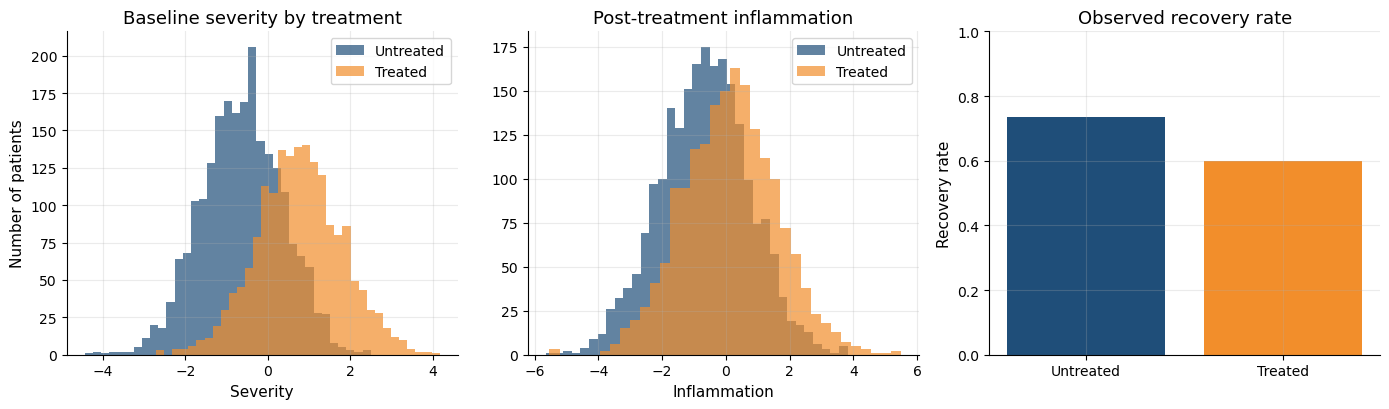

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Severity by treatment group
axes[0].hist(health.loc[health["Treatment"] == 0, "Severity"], bins=35, alpha=0.70,
             label="Untreated", color=COLORS["navy"])
axes[0].hist(health.loc[health["Treatment"] == 1, "Severity"], bins=35, alpha=0.70,
             label="Treated", color=COLORS["orange"])
axes[0].set_title("Baseline severity by treatment")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of patients")
axes[0].legend()
clean_axis(axes[0])

# Inflammation by treatment group
axes[1].hist(health.loc[health["Treatment"] == 0, "Inflammation"], bins=35, alpha=0.70,
             label="Untreated", color=COLORS["navy"])
axes[1].hist(health.loc[health["Treatment"] == 1, "Inflammation"], bins=35, alpha=0.70,
             label="Treated", color=COLORS["orange"])
axes[1].set_title("Post-treatment inflammation")
axes[1].set_xlabel("Inflammation")
axes[1].legend()
clean_axis(axes[1])

# Recovery rates by treatment group
rates = health.groupby("Treatment")["Recovery"].mean()
axes[2].bar(["Untreated", "Treated"], rates.values, color=[COLORS["navy"], COLORS["orange"]])
axes[2].set_title("Observed recovery rate")
axes[2].set_ylabel("Recovery rate")
axes[2].set_ylim(0, 1)
clean_axis(axes[2])

plt.tight_layout()
plt.show()

### Interpretation

The summary table and figures show that the treated and untreated groups are not directly comparable.

Patients who received treatment have a higher average baseline severity than untreated patients. In this simulated hospital setting, treatment assignment is not random: more severe patients are more likely to receive treatment. This creates a confounding problem because severity affects both the probability of receiving treatment and the probability of recovery.

The observed recovery rate is lower in the treated group than in the untreated group. At first glance, this may suggest that the treatment is harmful. However, this conclusion would be premature. The treated group starts from a worse baseline condition, so their lower recovery rate may reflect higher initial severity rather than a negative effect of treatment.

The post-treatment inflammation variable also differs between the two groups. However, this variable is measured after treatment, so it should be interpreted carefully. It may partly reflect the effect of treatment, patient severity, or both. Later in the chapter, we will see why adjusting for variables measured after treatment can sometimes create bias.

Therefore, the observed difference,

$P(Recovery = 1 \mid Treatment = 1) - P(Recovery = 1 \mid Treatment = 0)$,

is an associational comparison. It tells us what we observe in the hospital records, but it does not directly answer the causal question:

$P(Recovery = 1 \mid do(Treatment = 1)) - P(Recovery = 1 \mid do(Treatment = 0))$.

The main lesson is that causal graphs help us understand why a simple comparison between treated and untreated patients can be misleading. The graph will help us decide which variables are plausible confounders, which variables are downstream effects, and which variables should or should not be adjusted for when estimating a causal effect.

</br></br>

---
## 3. Directed Acyclic Graphs as causal assumption maps

A **Directed Acyclic Graph (DAG)** consists of:

- nodes, representing variables,
- directed edges, representing direct causal assumptions,
- no directed cycles, meaning a variable cannot cause itself through a directed path.

A graph is **acyclic** if there is no sequence such as $X_1 \rightarrow X_2 \rightarrow \cdots \rightarrow X_1$.

The DAG below summarizes our assumed data-generating process.

### Example: Assumed DAG for the healthcare case study

The DAG below summarizes the causal assumptions for the healthcare example used throughout this chapter. Each node represents a variable, and each arrow represents an assumed direct causal influence.

The main causal question is whether `Treatment` improves `Recovery`. However, the graph shows that this relationship is embedded in a larger system. For example, `Age`, `Socioeconomic`, `Severity`, and `Biomarker` may influence treatment assignment before treatment occurs. These variables are important because they can make treated and untreated patients different at baseline.

The graph also includes `Inflammation`, which is measured after treatment and may lie on the causal pathway from treatment to recovery:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

This makes `Inflammation` a possible mediator rather than a simple control variable.

</br>

Finally, the graph includes `SpecialistClinic`, which is affected by both `Severity` and `Access`:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

This is a collider structure. It helps illustrate why selecting only patients from a specialist clinic can create selection bias.

This DAG is not a result learned from the data. It is an **assumption map**: a transparent statement of how we believe the system may generate the observed data. Later sections use this graph to study confounding, mediation, collider bias, d-separation, and causal discovery.

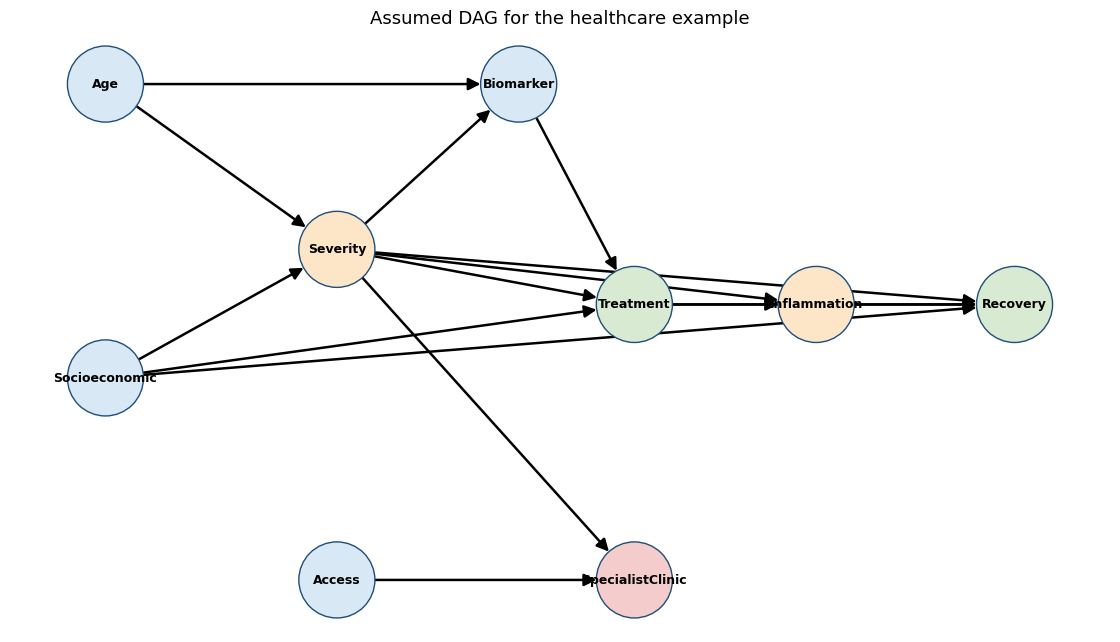

In [32]:
true_edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "Recovery"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Biomarker", "Treatment"),
    ("Severity", "Inflammation"),
    ("Treatment", "Inflammation"),
    ("Treatment", "Recovery"),
    ("Severity", "Recovery"),
    ("Inflammation", "Recovery"),
    ("Severity", "SpecialistClinic"),
    ("Access", "SpecialistClinic"),
]

pos = {
    "Age": (-2.7, 1.4),
    "Socioeconomic": (-2.7, -0.2),
    "Severity": (-1.3, 0.5),
    "Biomarker": (-0.2, 1.4),
    "Treatment": (0.5, 0.2),
    "Inflammation": (1.6, 0.2),
    "Recovery": (2.8, 0.2),
    "Access": (-1.3, -1.3),
    "SpecialistClinic": (0.5, -1.3),
}

node_colors = {
    "Age": COLORS["light_blue"],
    "Socioeconomic": COLORS["light_blue"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_blue"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_orange"],
    "Recovery": COLORS["light_green"],
    "Access": COLORS["light_blue"],
    "SpecialistClinic": COLORS["light_red"],
}

G_true = draw_dag(true_edges, pos=pos, title="Assumed DAG for the healthcare example", node_colors=node_colors, figsize=(11, 6));

### Reading the graph

The graph encodes several causal assumptions:

- `Severity` is a common cause of `Treatment`, `Inflammation`, `Recovery`, and `SpecialistClinic`.
- `Treatment` directly affects `Recovery` and indirectly affects `Recovery` through `Inflammation`.
- `SpecialistClinic` is a collider because it is caused by both `Severity` and `Access`.
- `Inflammation` is a mediator on the path `Treatment` $\rightarrow$ `Inflammation` $\rightarrow$ `Recovery`.

The graph is not automatically true. It is a structured statement of what we believe about the system.

**Note on node colors.**  
The colors are used only as visual teaching aids. 
- **Light blue** nodes indicate background or pre-treatment variables, such as `Age`, `Socioeconomic`, `Biomarker`, and `Access`. 
- **Light orange** nodes highlight variables with important causal roles, such as `Severity` as a confounder and `Inflammation` as a mediator. 
- **Light green** nodes indicate the main treatment-outcome pair, `Treatment` and `Recovery`. 
- **Light red** indicates a collider or selection variable, here `SpecialistClinic`.

The colors do not represent statistical significance, causal strength, or confidence in the edges.

</br></br>

---
## 4. Graph terminology

Let $G=(V,E)$ be a graph with nodes $V$ and edges $E$.

Important terms:

- **Node:** a variable, such as `Treatment` or `Recovery`.
- **Directed edge:** $X \rightarrow Y$, interpreted as a direct causal effect of $X$ on $Y$ under the assumed graph.
- **Path:** any sequence of connected nodes, regardless of arrow direction.
- **Directed path:** a path that follows arrow directions.
- **Parent:** $X$ is a parent of $Y$ if $X \rightarrow Y$.
- **Child:** $Y$ is a child of $X$ if $X \rightarrow Y$.
- **Ancestor:** $X$ is an ancestor of $Y$ if there is a directed path from $X$ to $Y$.
- **Descendant:** $Y$ is a descendant of $X$ if there is a directed path from $X$ to $Y$.

--- 
### Example: Inspecting graph relationships with Python

Once we define a causal graph, we can use Python to inspect the role of each variable in the graph.
The function below takes two inputs:

- `G`: the directed graph.
- `node`: the variable we want to inspect.

It returns four types of graph relationships:

- **Parents**: variables with direct arrows into the selected node.
- **Children**: variables that receive direct arrows from the selected node.
- **Ancestors**: variables that can reach the selected node through one or more directed paths.
- **Descendants**: variables that can be reached from the selected node through one or more directed paths.

The following code provides parent, child, ancestor, or descendant of **Treatment** and **Recovery** variable.

In [33]:
def graph_relations(G, node):
    return {
        "parents": sorted(list(G.predecessors(node))),
        "children": sorted(list(G.successors(node))),
        "ancestors": sorted(list(nx.ancestors(G, node))),
        "descendants": sorted(list(nx.descendants(G, node))),
    }

graph_relations(G_true, "Treatment")

{'parents': ['Biomarker', 'Severity', 'Socioeconomic'],
 'children': ['Inflammation', 'Recovery'],
 'ancestors': ['Age', 'Biomarker', 'Severity', 'Socioeconomic'],
 'descendants': ['Inflammation', 'Recovery']}

In [34]:
graph_relations(G_true, "Recovery")

{'parents': ['Inflammation', 'Severity', 'Socioeconomic', 'Treatment'],
 'children': [],
 'ancestors': ['Age',
  'Biomarker',
  'Inflammation',
  'Severity',
  'Socioeconomic',
  'Treatment'],
 'descendants': []}

</br></br>

---
## 5. Three Core DAG Structures

Most graphical reasoning in causal inference can be understood through three structures:

1. **Fork/confounder:** $X \leftarrow Z \rightarrow Y$
2. **Chain/mediator:** $X \rightarrow M \rightarrow Y$
3. **Collider:** $X \rightarrow C \leftarrow Y$

These structures determine whether a path is open or blocked under conditioning.

---
### 5.1 Fork Structure: Confounding

A fork occurs when a common cause affects two variables:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

Here, `Severity` is a confounder because it affects both treatment assignment and recovery.

If we ignore `Severity`, the association between `Treatment` and `Recovery` can be biased. Conditioning on the confounder can block the backdoor path.

### Example: Severity as a confounder in treatment evaluation

We now return to the healthcare case study introduced earlier in the chapter. The goal is to understand whether `Treatment` improves `Recovery`.

A simple comparison between treated and untreated patients may seem reasonable at first. However, in observational hospital data, treatment is usually not assigned randomly. Patients with higher baseline severity may be more likely to receive treatment. At the same time, severity can also affect the probability of recovery.

This creates the following causal structure:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This is called a **fork structure** because one variable, `Severity`, points toward two other variables. It is also a **confounding structure** because `Severity` creates a non-causal path between `Treatment` and `Recovery`.

In this example, we compare two quantities:

1. The **naive observed difference**, which compares recovery rates between treated and untreated patients.
2. An **adjusted estimate**, which compares treated and untreated patients after accounting for relevant pre-treatment variables.

The purpose is to show why the raw comparison can be misleading and how causal graphs help us decide what should be adjusted for.

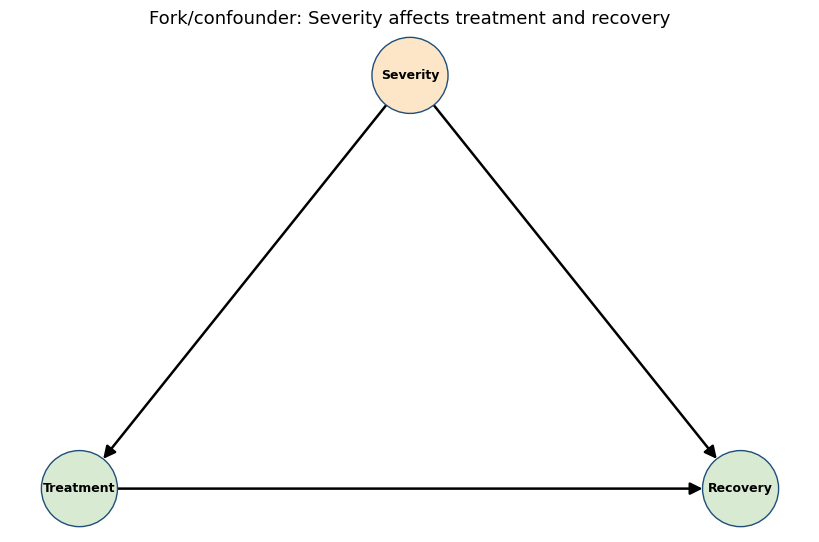

In [35]:
fork_edges = [("Severity", "Treatment"), ("Severity", "Recovery"), ("Treatment", "Recovery")]
fork_pos = {"Severity": (0, 1), "Treatment": (-1, 0), "Recovery": (1, 0)}
fork_colors = {"Severity": COLORS["light_orange"], "Treatment": COLORS["light_green"], "Recovery": COLORS["light_green"]}
G_fork = draw_dag(
    fork_edges,
    pos=fork_pos,
    title="Fork/confounder: Severity affects treatment and recovery",
    node_colors=fork_colors
);

Naive observed difference: -0.136
Adjusted estimate using pre-treatment variables: 0.167


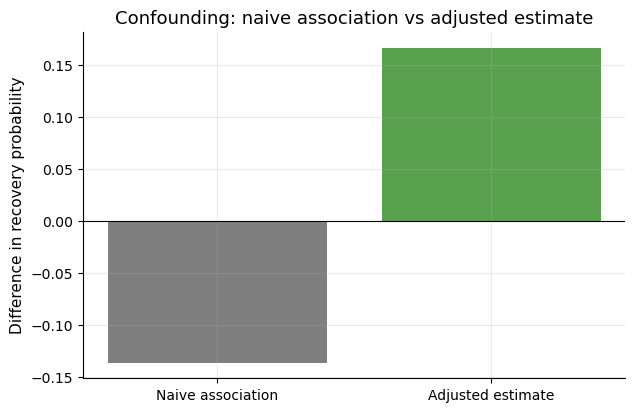

In [36]:
# Naive association
naive_treated = health.loc[health["Treatment"] == 1, "Recovery"].mean()
naive_untreated = health.loc[health["Treatment"] == 0, "Recovery"].mean()
naive_diff = naive_treated - naive_untreated

# Adjusted estimate using a simple outcome model with pre-treatment confounders
X_adj = health[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]]
y = health["Recovery"]
logit = LogisticRegression(max_iter=1000)
logit.fit(X_adj, y)

health_do1 = health.copy()
health_do0 = health.copy()
health_do1["Treatment"] = 1
health_do0["Treatment"] = 0

adj_do1 = logit.predict_proba(health_do1[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]])[:, 1].mean()
adj_do0 = logit.predict_proba(health_do0[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]])[:, 1].mean()
adj_diff = adj_do1 - adj_do0

print(f"Naive observed difference: {naive_diff:.3f}")
print(f"Adjusted estimate using pre-treatment variables: {adj_diff:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Naive association", "Adjusted estimate"], [naive_diff, adj_diff], color=[COLORS["gray"], COLORS["green"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Confounding: naive association vs adjusted estimate")
ax.set_ylabel("Difference in recovery probability")
clean_axis(ax)
plt.show()

### Interpretation

The graph shows that `Severity` is a common cause of both `Treatment` and `Recovery`. This creates a **backdoor path** between treatment and recovery:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This path is not the causal effect of treatment on recovery. Instead, it reflects the fact that treated and untreated patients differ before treatment is assigned.

The bar chart shows the consequence. The naive observed difference is negative:

$$P(Recovery=1 \mid Treatment=1) - P(Recovery=1 \mid Treatment=0) = -0.136$$

Taken literally, this would suggest that treated patients have a lower recovery probability than untreated patients. However, this conclusion is misleading because the treated group contains more severe patients.

After adjusting for pre-treatment variables, the estimated effect becomes positive:

$$0.167$$

This adjusted estimate is closer to the causal question we want to answer:

$$P(Recovery=1 \mid do(Treatment=1)) - P(Recovery=1 \mid do(Treatment=0))$$

The key lesson is that treatment can look harmful in the raw observational data even when it is beneficial. The reason is confounding: severity affects both treatment assignment and recovery.

To reduce this bias, we should adjust for appropriate **pre-treatment common causes** such as `Severity`. In graph language, conditioning on `Severity` helps block the backdoor path.

> Causal graphs help us identify which variables should be adjusted for before comparing treated and untreated groups.

---
### 5.2 Chain Structure: Mediation

A chain occurs when one variable transmits part of the effect of another variable:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

Here, `Inflammation` is a mediator. If the scientific question is the **total effect** of treatment on recovery, adjusting for the mediator can remove part of the effect we want to estimate.

This is an important distinction:

- Adjust for pre-treatment confounders when estimating a treatment effect.
- Do not adjust for post-treatment mediators when estimating the total effect.
- Adjusting for mediators may be useful for mediation analysis, but it changes the estimand.

### Example: Inflammation as a mediator of treatment effect

We continue with the same healthcare case study, but now we focus on a different type of causal structure.

Suppose the treatment affects recovery partly by changing the patient’s inflammation level after treatment. In this case, `Inflammation` lies on a causal path from `Treatment` to `Recovery`:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

In the graph, there is also a direct path from treatment to recovery:

$$Treatment \rightarrow Recovery$$

This means that treatment may improve recovery in two ways:

1. **Indirectly**, by changing inflammation.
2. **Directly**, through mechanisms not represented by inflammation.

A variable like `Inflammation`, which transmits part of the effect of a treatment to the outcome, is called a **mediator**.

In this example, we compare two adjusted estimates:

1. An estimate that adjusts only for appropriate **pre-treatment variables**.
2. An estimate that also adjusts for the **mediator** `Inflammation`.

The purpose is to show that including a mediator in the adjustment set changes the question we are answering.

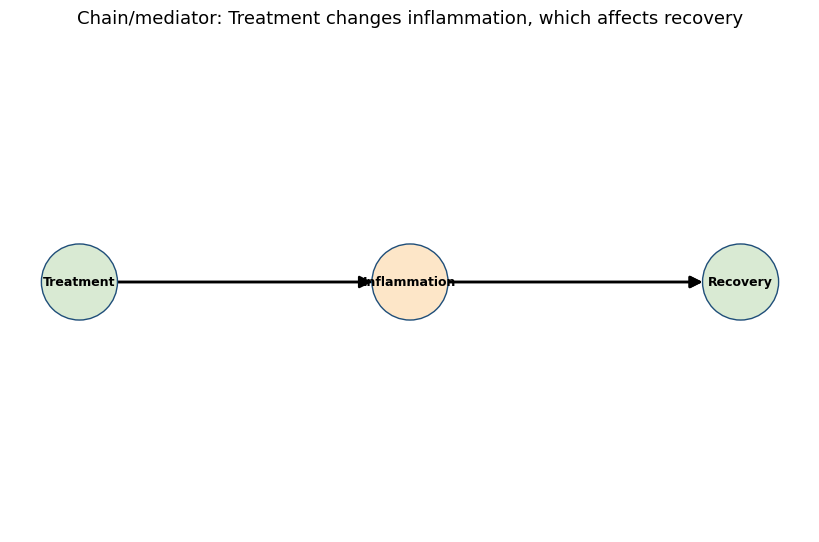

In [37]:
chain_edges = [("Treatment", "Inflammation"), ("Inflammation", "Recovery"), ("Treatment", "Recovery")]
chain_pos = {"Treatment": (-1.2, 0), "Inflammation": (0, 0), "Recovery": (1.2, 0)}
chain_colors = {"Treatment": COLORS["light_green"], "Inflammation": COLORS["light_orange"], "Recovery": COLORS["light_green"]}
G_chain = draw_dag(
    chain_edges,
    pos=chain_pos,
    title="Chain/mediator: Treatment changes inflammation, which affects recovery",
    node_colors=chain_colors
);

Adjusted estimate without mediator: 0.167
Adjusted estimate with mediator included: 0.100


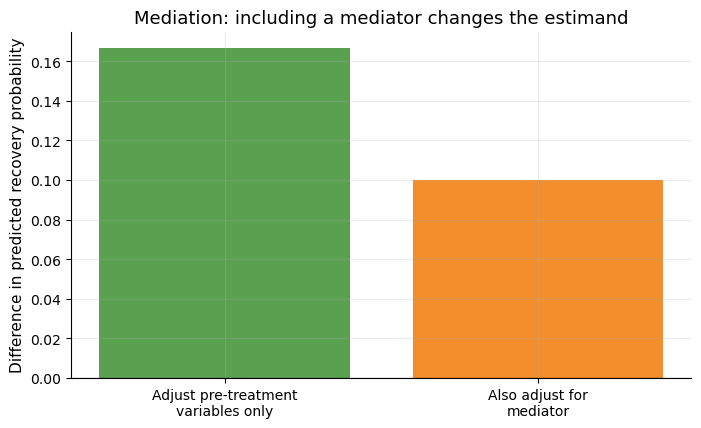

In [38]:
# Compare outcome models with and without the mediator
pre_treatment_vars = ["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]
mediator_model_vars = pre_treatment_vars + ["Inflammation"]

model_total = LogisticRegression(max_iter=1000).fit(health[pre_treatment_vars], health["Recovery"])
model_direct = LogisticRegression(max_iter=1000).fit(health[mediator_model_vars], health["Recovery"])

do1 = health.copy(); do1["Treatment"] = 1
do0 = health.copy(); do0["Treatment"] = 0

# Total-effect style prediction: do not hold mediator fixed
est_total = (
    model_total.predict_proba(do1[pre_treatment_vars])[:, 1].mean()
    - model_total.predict_proba(do0[pre_treatment_vars])[:, 1].mean()
)

# Direct-effect style association: holds observed mediator fixed in the model
est_with_mediator = (
    model_direct.predict_proba(do1[mediator_model_vars])[:, 1].mean()
    - model_direct.predict_proba(do0[mediator_model_vars])[:, 1].mean()
)

print(f"Adjusted estimate without mediator: {est_total:.3f}")
print(f"Adjusted estimate with mediator included: {est_with_mediator:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    ["Adjust pre-treatment\nvariables only", "Also adjust for\nmediator"],
    [est_total, est_with_mediator],
    color=[COLORS["green"], COLORS["orange"]]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mediation: including a mediator changes the estimand")
ax.set_ylabel("Difference in predicted recovery probability")
clean_axis(ax)
plt.show()

### Interpretation

`Inflammation` is a **post-treatment variable**: it can be changed by the treatment itself, and it also affects recovery. Because of this, it is a mediator rather than a confounder.

The first estimate, which adjusts only for pre-treatment variables, is:

$$0.167$$

This is the better estimate of the **total effect** of treatment on recovery, because it keeps both the direct path and the indirect path through inflammation.

When `Inflammation` is also included in the adjustment set, the estimate becomes smaller:

$$0.100$$

*Why does this happen?*  
Because adjusting for the mediator blocks part of the treatment effect that flows through the path

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

As a result, the second estimate no longer represents the total effect of treatment. Instead, it is closer to a **direct effect**, meaning the part of the treatment effect that does not operate through inflammation.

The key lesson is:

- If our goal is to estimate the **total causal effect** of treatment, we usually should **not adjust for mediators**.
- If our goal is to isolate a **direct effect**, then adjusting for the mediator may be appropriate, but the estimand changes.

So, unlike a confounder, a mediator is not something we automatically control for. Causal graphs help us distinguish between these roles and avoid adjusting for a variable that lies on the causal pathway from treatment to outcome.

---
### 5.3 Collider Structure: Selection Bias

A collider occurs when two variables cause a common effect:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

Before conditioning on `SpecialistClinic`, `Severity` and `Access` are approximately independent because they were generated independently.

After conditioning on `SpecialistClinic=1`, an association can appear. This is a selection effect: among patients who enter the specialist clinic, high severity can compensate for low access, and high access can compensate for lower severity.

The key rule is:

> **Conditioning on a collider opens a path that was previously closed.**

### Example: Specialist clinic admission as a collider

We continue with the healthcare case study, but now we examine a different source of bias: **selection bias**.

Suppose that admission to a specialist clinic depends on two factors:

1. `Severity`: patients with more severe illness are more likely to be admitted.
2. `Access`: patients with better access to healthcare resources are also more likely to be admitted.

This creates the following structure:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

This is called a **collider structure** because two arrows point into the same variable, `SpecialistClinic`.

In the full population, `Severity` and `Access` may be unrelated. However, if we restrict the analysis only to patients admitted to the specialist clinic, we are conditioning on the collider. This can create an artificial association between `Severity` and `Access`, even if no such relationship exists in the full population.

The purpose of this example is to show why datasets created through selection processes can be misleading. Hospital records, specialist clinic data, insurance claims, customer complaints, and incident databases often include only selected cases. If selection depends on multiple variables, conditioning on the selected sample can distort the relationships among those variables.

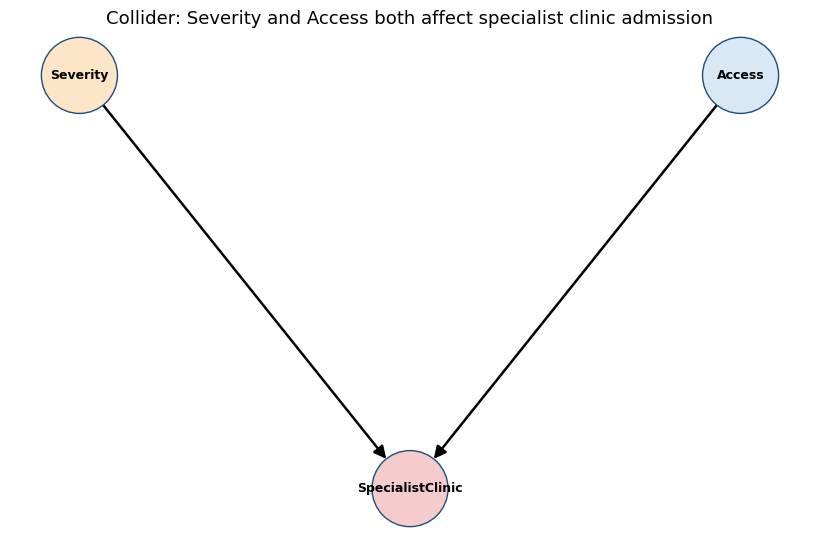

In [39]:
collider_edges = [("Severity", "SpecialistClinic"), ("Access", "SpecialistClinic")]
collider_pos = {"Severity": (-1, 0.7), "Access": (1, 0.7), "SpecialistClinic": (0, -0.4)}
collider_colors = {"Severity": COLORS["light_orange"], "Access": COLORS["light_blue"], "SpecialistClinic": COLORS["light_red"]}
G_collider = draw_dag(
    collider_edges,
    pos=collider_pos,
    title="Collider: Severity and Access both affect specialist clinic admission",
    node_colors=collider_colors
);

Correlation between Severity and Access in full data: -0.009
Correlation between Severity and Access among SpecialistClinic=1: -0.214


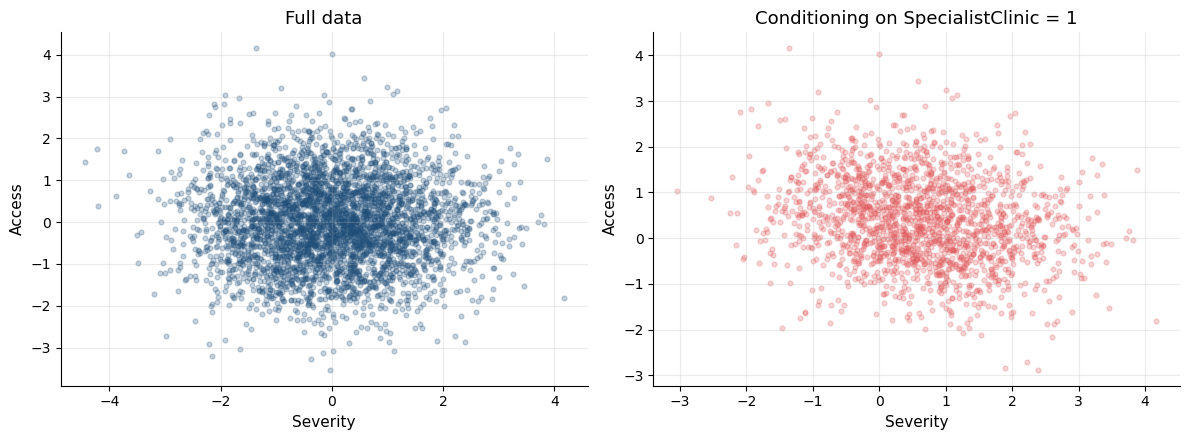

In [40]:
# Marginal correlation between Severity and Access
corr_all = health[["Severity", "Access"]].corr().iloc[0, 1]

# Correlation after conditioning on the collider SpecialistClinic = 1
clinic = health[health["SpecialistClinic"] == 1]
corr_clinic = clinic[["Severity", "Access"]].corr().iloc[0, 1]

print(f"Correlation between Severity and Access in full data: {corr_all:.3f}")
print(f"Correlation between Severity and Access among SpecialistClinic=1: {corr_clinic:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(health["Severity"], health["Access"], alpha=0.25, color=COLORS["navy"], s=12)
axes[0].set_title("Full data")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Access")
clean_axis(axes[0])

axes[1].scatter(clinic["Severity"], clinic["Access"], alpha=0.25, color=COLORS["red"], s=12)
axes[1].set_title("Conditioning on SpecialistClinic = 1")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Access")
clean_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

The graph shows that both `Severity` and `Access` affect admission to the specialist clinic:

$$Severity \rightarrow SpecialistClinic$$

$$Access \rightarrow SpecialistClinic$$

Here, `SpecialistClinic` is a **collider** because it is a common effect of two variables.

In the full dataset, the correlation between `Severity` and `Access` is close to zero:

$$Corr(Severity, Access) = 0.009$$

This means that, before conditioning on clinic admission, there is little or no association between these two variables.

However, after restricting the data to patients admitted to the specialist clinic, the correlation becomes clearly negative:

$$Corr(Severity, Access \mid SpecialistClinic = 1) = -0.214$$

This negative association is not necessarily a real causal relationship. It appears because we selected only patients who entered the specialist clinic. Among admitted patients, a person may enter because of high severity, high access, or both. If one factor is lower, the other often needs to be higher for the patient to appear in the selected group.

For example, among patients in the specialist clinic:

- a patient with high severity may be admitted even with limited access,
- a patient with lower severity may need better access to be admitted.

This creates an artificial trade-off between `Severity` and `Access` inside the selected sample.

The key lesson is that conditioning on a collider can create a spurious association between its causes. Therefore, we should be careful when analyzing data that only include selected cases.

> Unlike confounders, colliders should generally not be adjusted for. Conditioning on a collider can open a path that was previously closed and introduce selection bias.

</br></br>

---
## 6. d-Separation and Conditional Independence

**d-separation** is a graphical criterion for deciding whether a path between two variables is blocked or open given a conditioning set.

A path is blocked if one of the following holds:

1. The path contains a chain $X \rightarrow M \rightarrow Y$ or $X \leftarrow M \leftarrow Y$, and we condition on $M$.
2. The path contains a fork $X \leftarrow Z \rightarrow Y$, and we condition on $Z$.
3. The path contains a collider $X \rightarrow C \leftarrow Y$, and neither $C$ nor a descendant of $C$ is conditioned on.

A path is opened by conditioning on a collider or a descendant of a collider.

Graphical independence is written as:

$$X \perp Y \mid Z$$

which means: $X$ is independent of $Y$ conditional on $Z$, under the assumptions encoded by the graph.

### Examples in our graph

1. **Confounding path:**  
   `Treatment` $\leftarrow$ `Severity` $\rightarrow$ `Recovery`  
   This path is open unless we adjust for `Severity` or a sufficient set of pre-treatment variables.

2. **Mediation path:**  
   `Treatment` $\rightarrow$ `Inflammation` $\rightarrow$ `Recovery`  
   Conditioning on `Inflammation` blocks the indirect path.

3. **Collider path:**  
   `Severity` $\rightarrow$ `SpecialistClinic` $\leftarrow$ `Access`  
   This path is closed by default, but opens when conditioning on `SpecialistClinic`.


<div style="text-align: center;">
  <img src="img/CH02/DAG-Treatment-Severity-Recovery.png" alt="DAG for Treatment-Severity-Recovery Example" width="700"/>
</div>
   

### Two key assumptions behind graph-based reasoning

Before connecting d-separation to patterns in the data, we need two important assumptions.

The **Causal Markov Condition** says that the causal graph implies certain conditional independence relationships in the data. Informally, once we condition on the direct causes of a variable, that variable is independent of other non-descendant variables.

The **Faithfulness Assumption** says the reverse: the conditional independencies we observe in the data are due to the graph structure, not accidental numerical cancellations.

Together, these assumptions create the bridge between graphs and data:

- The graph suggests which variables should become independent after conditioning.
- The data can be checked to see whether those independence patterns are approximately present.

This bridge is essential for causal discovery. Discovery algorithms such as PC use conditional independence tests to remove or retain candidate edges in a graph.

However, these assumptions can fail. For example, two causal paths may cancel each other numerically, making variables appear independent even when a causal connection exists. Measurement error, small sample size, nonlinear relationships, and hidden confounders can also make conditional independence tests unreliable.

Therefore, partial correlation and conditional independence tests should be used as diagnostics, not as automatic proof of causality.

### Example: Using partial correlation to build intuition

d-separation is a graphical concept. It tells us whether a path between two variables is open or blocked in a causal graph, given a conditioning set.

In data analysis, we often want to see whether this graphical idea is reflected in the observed data. One simple diagnostic is **partial correlation**.

A partial correlation measures the association between two variables after removing the linear association with a set of control variables.

For example, suppose we want to examine the relationship between `Treatment` and `Recovery` after accounting for `Severity`. We can first regress `Treatment` on `Severity` and keep the residuals. We then regress `Recovery` on `Severity` and keep those residuals. The correlation between the two residual series is the partial correlation.

The code below defines two helper functions:

- `residualize(y, X)`: removes the linear association between a variable `y` and a set of variables `X`.
- `partial_corr(df, x, y, controls)`: computes the correlation between `x` and `y` after adjusting for the variables listed in `controls`.

We then compare several cases from the chapter:

1. The raw association between `Treatment` and `Recovery`.
2. The association after adjusting for pre-treatment variables.
3. The association after also adjusting for the mediator `Inflammation`.
4. The raw association between `Severity` and `Access`.
5. The association between `Severity` and `Access` after conditioning on the collider `SpecialistClinic`.

> This example is not meant to prove causal effects. It is meant to show how different conditioning choices can change the observed statistical association in ways that match the graphical intuition.

</br>

To make the connection between conditioning and graph structure easier to follow, each row in the table is linked to a tagged mini-DAG. The table reports the correlation or partial correlation, while the corresponding graph shows the causal pattern behind the conditioning choice.

,Tag,X,Y,Conditioning set,Graph pattern,DAG relationship,Correlation / partial correlation
0,A,Treatment,Recovery,None,Naive association,Treatment → Recovery,-0.144161
1,B,Treatment,Recovery,"Severity, Biomarker, Age, Socioeconomic",Fork / confounding adjusted,Treatment ← Severity → Recovery,0.175411
2,C,Treatment,Recovery,"Severity, Biomarker, Age, Socioeconomic, Infla...",Chain / mediator included,Treatment → Inflammation → Recovery,0.097026
3,D,Severity,Access,None,Marginal independence,Severity Access,-0.008629
4,E,Severity,Access,SpecialistClinic,Collider conditioned on,Severity → SpecialistClinic ← Access,-0.203946


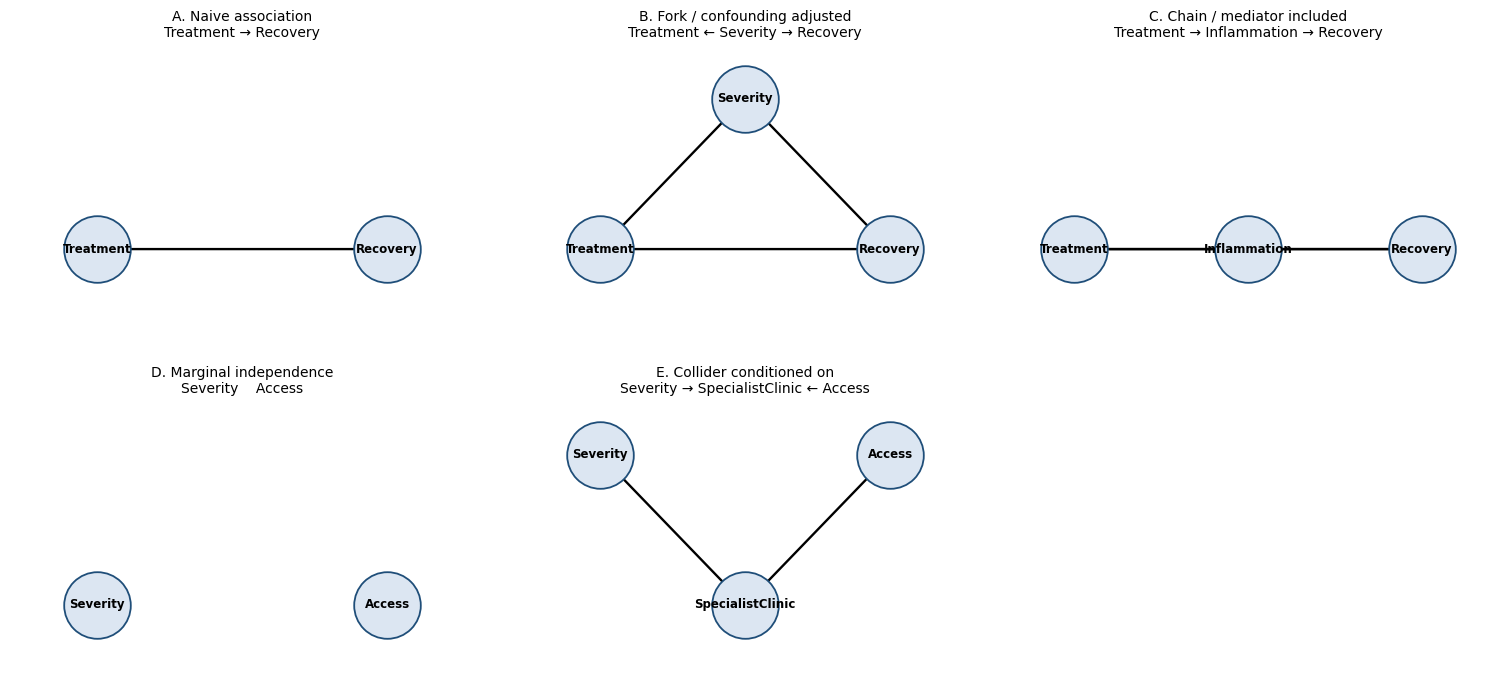

In [41]:
# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def residualize(y, X):
    """
    Return residuals from a linear regression of y on X.

    This removes the linear association between y and the control variables X.
    """
    y = np.asarray(y).reshape(-1)
    X = np.asarray(X)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    model = LinearRegression().fit(X, y)
    residuals = y - model.predict(X)

    return residuals


def partial_corr(df, x, y, controls=None):
    """
    Compute correlation or partial correlation.

    If no controls are provided, this returns the ordinary correlation
    between x and y.

    If controls are provided, this returns the correlation between:
    - residuals of x after regressing x on controls
    - residuals of y after regressing y on controls
    """
    controls = controls or []

    if len(controls) == 0:
        return df[[x, y]].corr().iloc[0, 1]

    rx = residualize(df[x], df[controls])
    ry = residualize(df[y], df[controls])

    return np.corrcoef(rx, ry)[0, 1]


# ---------------------------------------------------------------------
# Define examples: each row links a statistical result to a DAG pattern
# ---------------------------------------------------------------------

examples = [
    {
        "tag": "A",
        "x": "Treatment",
        "y": "Recovery",
        "controls": [],
        "graph_pattern": "Naive association",
        "dag_label": "Treatment → Recovery",
        "edges": [("Treatment", "Recovery")],
        "pos": {
            "Treatment": (-1.0, 0.0),
            "Recovery": (1.0, 0.0),
        },
    },
    {
        "tag": "B",
        "x": "Treatment",
        "y": "Recovery",
        "controls": ["Severity", "Biomarker", "Age", "Socioeconomic"],
        "graph_pattern": "Fork / confounding adjusted",
        "dag_label": "Treatment ← Severity → Recovery",
        "edges": [
            ("Severity", "Treatment"),
            ("Severity", "Recovery"),
            ("Treatment", "Recovery"),
        ],
        "pos": {
            "Severity": (0.0, 1.0),
            "Treatment": (-1.0, 0.0),
            "Recovery": (1.0, 0.0),
        },
    },
    {
        "tag": "C",
        "x": "Treatment",
        "y": "Recovery",
        "controls": ["Severity", "Biomarker", "Age", "Socioeconomic", "Inflammation"],
        "graph_pattern": "Chain / mediator included",
        "dag_label": "Treatment → Inflammation → Recovery",
        "edges": [
            ("Treatment", "Inflammation"),
            ("Inflammation", "Recovery"),
            ("Treatment", "Recovery"),
        ],
        "pos": {
            "Treatment": (-1.2, 0.0),
            "Inflammation": (0.0, 0.0),
            "Recovery": (1.2, 0.0),
        },
    },
    {
        "tag": "D",
        "x": "Severity",
        "y": "Access",
        "controls": [],
        "graph_pattern": "Marginal independence",
        "dag_label": "Severity    Access",
        "edges": [],
        "pos": {
            "Severity": (-1.0, 0.0),
            "Access": (1.0, 0.0),
        },
    },
    {
        "tag": "E",
        "x": "Severity",
        "y": "Access",
        "controls": ["SpecialistClinic"],
        "graph_pattern": "Collider conditioned on",
        "dag_label": "Severity → SpecialistClinic ← Access",
        "edges": [
            ("Severity", "SpecialistClinic"),
            ("Access", "SpecialistClinic"),
        ],
        "pos": {
            "Severity": (-1.0, 1.0),
            "Access": (1.0, 1.0),
            "SpecialistClinic": (0.0, 0.0),
        },
    },
]


# ---------------------------------------------------------------------
# Build and display the results table
# ---------------------------------------------------------------------

rows = []

for ex in examples:
    rows.append({
        "Tag": ex["tag"],
        "X": ex["x"],
        "Y": ex["y"],
        "Conditioning set": ", ".join(ex["controls"]) if ex["controls"] else "None",
        "Graph pattern": ex["graph_pattern"],
        "DAG relationship": ex["dag_label"],
        "Correlation / partial correlation": partial_corr(
            health,
            ex["x"],
            ex["y"],
            ex["controls"]
        ),
    })

results_df = pd.DataFrame(rows)

display(results_df)


# ---------------------------------------------------------------------
# Plot mini-DAGs in two rows
# ---------------------------------------------------------------------

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 7))
axes = axes.flatten()

for ax, ex in zip(axes, examples):
    G = nx.DiGraph()

    # Add nodes and edges
    nodes = list(ex["pos"].keys())
    G.add_nodes_from(nodes)
    G.add_edges_from(ex["edges"])

    nx.draw_networkx_nodes(
        G,
        pos=ex["pos"],
        ax=ax,
        node_size=2300,
        node_color="#DCE6F2",
        edgecolors="#1F4E79",
        linewidths=1.3,
    )

    nx.draw_networkx_edges(
        G,
        pos=ex["pos"],
        ax=ax,
        arrows=True,
        arrowsize=18,
        width=1.7,
        edge_color="black",
        connectionstyle="arc3,rad=0.0",
    )

    nx.draw_networkx_labels(
        G,
        pos=ex["pos"],
        ax=ax,
        font_size=8.5,
        font_weight="bold",
    )

    ax.set_title(
        f"{ex['tag']}. {ex['graph_pattern']}\n{ex['dag_label']}",
        fontsize=10,
        pad=12,
    )

    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-0.5, 1.3)
    ax.axis("off")

# Hide the unused sixth panel
for ax in axes[len(examples):]:
    ax.axis("off")

plt.tight_layout(h_pad=3.0, w_pad=2.8)
plt.show()

### Interpretation

The table shows how the association between two variables changes when we condition on different sets of variables.

For `Treatment` and `Recovery`, the raw correlation is negative:

$$Corr(Treatment, Recovery) = -0.145$$

This reflects the naive observational comparison. Treated patients appear to have lower recovery rates, but this is misleading because treatment is more common among severe patients.

After conditioning on pre-treatment variables such as `Severity`, `Biomarker`, `Age`, and `Socioeconomic`, the partial correlation becomes positive:

$$Corr(Treatment, Recovery \mid Severity, Biomarker, Age, Socioeconomic) = 0.175$$

This is consistent with the confounding example. Once we compare patients with similar pre-treatment characteristics, treatment is positively associated with recovery.

However, when we also condition on `Inflammation`, the partial correlation becomes smaller:

$$Corr(Treatment, Recovery \mid Severity, Biomarker, Age, Socioeconomic, Inflammation) = 0.097$$

This happens because `Inflammation` is a mediator. It lies on the causal pathway from treatment to recovery:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

Conditioning on it removes part of the pathway through which treatment affects recovery. Therefore, this estimate no longer represents the same causal question as the total effect.

</br></br>

For `Severity` and `Access`, the raw correlation is close to zero:

$$Corr(Severity, Access) = -0.009$$

This suggests little or no association in the full population.

After conditioning on `SpecialistClinic`, the correlation becomes clearly negative:

$$Corr(Severity, Access \mid SpecialistClinic) = -0.209$$

This is the collider example. `SpecialistClinic` is a common effect of both `Severity` and `Access`:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

Conditioning on this collider opens a path between `Severity` and `Access`, creating an association that was not present in the full data.

</br></br>

> The main lesson is that conditioning is not automatically good or bad. Its effect depends on the role of the variable in the causal graph.
> - Conditioning on a confounder can reduce bias.
> - Conditioning on a mediator can change the estimand.
> - Conditioning on a collider can create bias.


<font color='blue'>
Partial correlation is useful as a statistical diagnostic, but it is not the same as d-separation. d-separation is a statement about the graph and its implied independence relations. Partial correlation is a numerical pattern observed in the data. We use both together: the graph tells us what to expect, and the data help us examine whether the pattern is plausible.
</font>

</br></br>

---
## 7. Backdoor paths and adjustment

Suppose we want to estimate the causal effect of `Treatment` on `Recovery` in the same healthcare example.

The ideal causal question is:

$$P(Recovery \mid do(Treatment=t))$$

This asks what recovery would look like if we actively assigned `Treatment`. However, in observational data, treatment is not assigned randomly. Patients receive treatment for reasons, and some of those reasons may also affect `Recovery`.

This is where **backdoor paths** become important.

A **backdoor path** is any path from `Treatment` to `Recovery` that begins with an arrow into `Treatment`.

In other words, a backdoor path enters the treatment variable from behind. It represents a source of association between treatment and outcome that is not caused by the treatment itself.

<div style="text-align: center;">
  <img src="img/CH02/DAG-Treatment-Severity-Recovery.png" alt="DAG for Treatment-Severity-Recovery Example" width="700"/>
</div>

</br>

In our graph, one important backdoor path is:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This path tells us that `Severity` affects both `Treatment` assignment and `Recovery`. More severe patients may be more likely to receive treatment, but they may also be less likely to recover. Therefore, a simple comparison between treated and untreated patients mixes two things:

1. the possible causal effect of treatment, and
2. pre-existing differences between patients.

From a **causal inference perspective**, a backdoor path is a source of confounding. It creates a non-causal route through which `Treatment` and `Recovery` become associated.

From a **data analytics perspective**, this means that the observed relationship between `Treatment` and `Recovery` may be misleading. A model may find that treatment is associated with lower recovery, not because treatment is harmful, but because treated patients were more severe at baseline.

</br>

Another backdoor path in our graph is:

$$Treatment \leftarrow Biomarker \leftarrow Severity \rightarrow Recovery$$

Here, `Biomarker` is also part of a pre-treatment route connecting `Treatment` assignment to `Recovery`. If such paths remain open, the estimated treatment effect may be biased.

The goal of adjustment is to block these non-causal paths while keeping the causal path from treatment to outcome open.

A set of variables $Z$ satisfies the **backdoor criterion** if:

1. no variable in $Z$ is a descendant of `Treatment`, and
2. $Z$ blocks every path between `Treatment` and `Recovery` that begins with an arrow into `Treatment`.

If this condition holds, the causal effect can be identified by adjustment:

$$P(Y\mid do(T=t)) = \sum_z P(Y\mid T=t, Z=z)P(Z=z)$$

This formula means that we compare treated and untreated patients within comparable groups defined by $Z$, and then average those comparisons over the population distribution of $Z$.

For continuous variables, the summation is replaced by integration.

The practical message is:

> Backdoor adjustment helps us transform a biased observational comparison into a more credible causal comparison, provided that the adjustment variables are correctly chosen and measured.

### Practical adjustment rule for this example

For the total effect of `Treatment` on `Recovery`, a reasonable adjustment set is:

$$Z = \{Age, Socioeconomic, Severity, Biomarker\}$$

This set contains pre-treatment variables that help block backdoor paths into `Treatment`.

Variables that should generally not be included for the total effect include:

- `Inflammation`, because it is a mediator after treatment,
- `SpecialistClinic`, because it is a collider/selection variable,
- descendants of the treatment, because they can change the causal estimand or introduce bias.

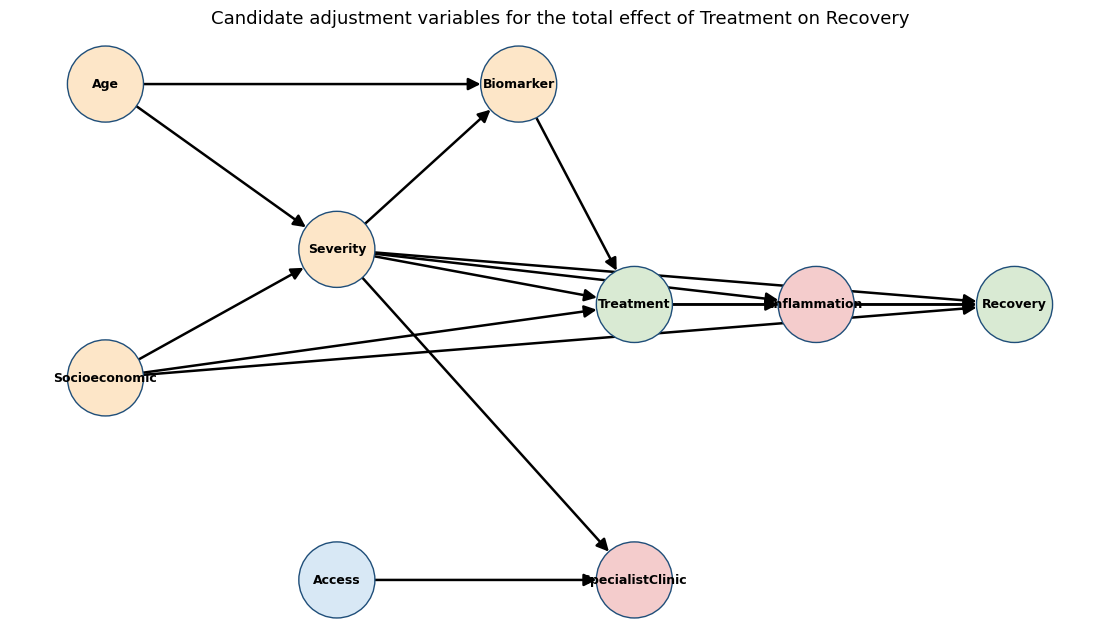

In [42]:
# Highlight a suitable adjustment set
adjustment_edges = true_edges
adjustment_colors = {node: COLORS["light_blue"] for node in G_true.nodes()}
for node in ["Severity", "Biomarker", "Age", "Socioeconomic"]:
    adjustment_colors[node] = COLORS["light_orange"]
adjustment_colors["Treatment"] = COLORS["light_green"]
adjustment_colors["Recovery"] = COLORS["light_green"]
adjustment_colors["Inflammation"] = COLORS["light_red"]
adjustment_colors["SpecialistClinic"] = COLORS["light_red"]

G_adjustment = draw_dag(
    adjustment_edges,
    pos=pos,
    title="Candidate adjustment variables for the total effect of Treatment on Recovery",
    node_colors=adjustment_colors,
    figsize=(11, 6)
);

### Example: Backdoor adjustment using an outcome model

The backdoor adjustment formula says that we should compare treated and untreated patients after accounting for an appropriate set of pre-treatment variables.

In this example, we use a simple logistic regression outcome model to implement this idea. This is not the only way to perform adjustment, but it provides a practical and intuitive implementation of the backdoor criterion.

We use the following adjustment set:

$$Z = \{Severity, Biomarker, Age, Socioeconomic\}$$

These variables are measured before treatment and help block backdoor paths from `Treatment` to `Recovery`.

The model estimates recovery as a function of treatment and the adjustment variables:

$$P(Recovery=1 \mid Treatment, Severity, Biomarker, Age, Socioeconomic)$$

After fitting the model, we create two hypothetical versions of the same dataset:

1. A version where every patient is assigned treatment: `Treatment = 1`.
2. A version where every patient is assigned no treatment: `Treatment = 0`.

Importantly, all pre-treatment patient characteristics remain the same in both hypothetical datasets. This means we compare treatment and no treatment over the same population distribution of severity, biomarkers, age, and socioeconomic status.

The difference between the two average predicted recovery probabilities approximates the causal contrast:

$$P(Recovery=1 \mid do(Treatment=1)) - P(Recovery=1 \mid do(Treatment=0))$$

In [43]:
# Backdoor adjustment using a simple outcome model

adjustment_set = ["Severity", "Biomarker", "Age", "Socioeconomic"]

X_backdoor = health[["Treatment"] + adjustment_set]
y = health["Recovery"]

backdoor_model = LogisticRegression(max_iter=1000)
backdoor_model.fit(X_backdoor, y)

do_treat = health.copy()
do_control = health.copy()

do_treat["Treatment"] = 1
do_control["Treatment"] = 0

p_do_treat = backdoor_model.predict_proba(do_treat[["Treatment"] + adjustment_set])[:, 1].mean()
p_do_control = backdoor_model.predict_proba(do_control[["Treatment"] + adjustment_set])[:, 1].mean()
backdoor_effect = p_do_treat - p_do_control

print(f"P(Recovery=1 | do(Treatment=1)) estimate: {p_do_treat:.3f}")
print(f"P(Recovery=1 | do(Treatment=0)) estimate: {p_do_control:.3f}")
print(f"Backdoor-adjusted treatment effect estimate: {backdoor_effect:.3f}") 

P(Recovery=1 | do(Treatment=1)) estimate: 0.750
P(Recovery=1 | do(Treatment=0)) estimate: 0.584
Backdoor-adjusted treatment effect estimate: 0.167


### Interpretation

The code implements backdoor adjustment using **model-based standardization**.

First, we fit an outcome model using `Treatment` and the selected pre-treatment adjustment variables: `Severity`, `Biomarker`, `Age`, and `Socioeconomic`.

Then we use the fitted model to predict recovery under two hypothetical intervention scenarios:

$$do(Treatment=1)$$

and

$$do(Treatment=0)$$

The results are:

$$P(Recovery=1 \mid do(Treatment=1)) \approx 0.750$$

$$P(Recovery=1 \mid do(Treatment=0)) \approx 0.584$$

The estimated backdoor-adjusted treatment effect is therefore:

$$0.750 - 0.584 = 0.167$$

This means that, after adjusting for the selected pre-treatment variables, assigning treatment is estimated to increase the probability of recovery by about **16.7 percentage points**.

This result should be compared with the naive observational comparison from earlier in the chapter, where treated patients appeared to have worse recovery outcomes. The adjusted result is different because it compares treatment and no treatment over the same distribution of pre-treatment patient characteristics.

The key idea is that we are no longer simply comparing the patients who happened to receive treatment with those who did not. Instead, we are asking:

> *For the same population of patients, what would the predicted recovery rate be if everyone were treated versus if no one were treated?*

This is why backdoor adjustment moves us closer to the causal question.

However, this estimate is only credible if the adjustment set is appropriate and the outcome model is reasonably specified. If important confounders are missing, measured incorrectly, or modeled poorly, the adjusted estimate may still be biased.

</br>

---
## 8. From Assumed Graphs to Data-supported Graphs

So far, we have used a causal graph as an **assumption map**. We started with a DAG based on domain knowledge and used it to reason about confounding, mediation, collider bias, d-separation, and adjustment.

This is the usual starting point in applied causal inference: we begin with scientific knowledge about the system.

However, in real research, the graph is rarely fully known. We may know some things with confidence. For example, baseline `Age` cannot be caused by later `Recovery`. But other relationships may be uncertain:

- Does `Biomarker` directly affect `Recovery`, or only through `Treatment`?
- Does `Socioeconomic` directly affect `Recovery`, or only through `Severity` and `Treatment`?
- Which variables remain associated after conditioning on other variables?
- Which edges are supported by the observed data?
- Which edges are plausible but uncertain?

This is where causal discovery becomes useful.

Causal discovery does not replace domain knowledge. Instead, it helps us use data to propose, test, and refine candidate graph structures.

The bridge between graphical reasoning and causal discovery is **conditional independence**.

In **d-separation**, we start from a graph and ask:

> *Which variables should be independent after conditioning on a set of variables?*

In **causal discovery**, we often start from data and ask the reverse question:

> *Which graph structures could explain the conditional independence patterns we observe?*

For example:

- If two variables are nearly independent in the full data, a direct edge between them may be unnecessary.
- If two variables become nearly independent after conditioning on a third variable, that third variable may help explain the path between them.
- If two variables become associated only after conditioning on a third variable, that third variable may be a collider.

> Therefore, causal discovery can be understood as a data-assisted way to generate **candidate causal graphs**. **The result is not automatically the true graph**. It must be evaluated using domain knowledge, temporal ordering, assumptions, robustness checks, and, where possible, interventional evidence.


</br></br>

---
## 9. Causal Discovery as Graph Refinement

Causal discovery asks whether the observed data can help us propose or refine a causal graph.

In this chapter, we already used a known DAG for teaching because the dataset is simulated. **In real research, however, the true graph is rarely known**. We usually combine three sources of information:

1. **Domain knowledge**, such as temporal ordering and impossible directions.
2. **Graphical reasoning**, such as d-separation, backdoor paths, and collider structures.
3. **Statistical evidence**, such as marginal and conditional independence patterns in the data.

Causal discovery methods formalize the third part. They use statistical patterns in the data to generate candidate graph structures.

Causal discovery is useful when experiments are impossible, expensive, or unethical. Examples include:

- gene regulatory network discovery,
- causal structure learning in operational energy systems,
- climate mechanisms discovery,
- medical hypothesis generation from observational patient records.

A careful interpretation is:

> **Causal discovery does not discover causal truth automatically.** It generates candidate graphs that should be checked against domain knowledge, assumptions, temporal logic, and, when possible, experimental or interventional evidence.


---
### 9.1 Main families of causal discovery methods

| Family | Basic idea | Examples | Main strengths | Main limitations |
|---|---|---|---|---|
| **Independence-based** | Use conditional independence tests | [PC](https://mitpress.mit.edu/9780262194402/causation-prediction-and-search/), [FCI](https://arxiv.org/pdf/1302.4983), [RFCI](https://projecteuclid.org/journals/annals-of-statistics/volume-40/issue-1/Learning-high-dimensional-directed-acyclic-graphs-with-latent-and-selection/10.1214/11-AOS940.pdf) | Transparent, statistically grounded | Sensitive to CI test errors and sample size |
| **Score-based** | Search for graphs with high score | [GES](https://www.jmlr.org/papers/volume3/chickering02b/chickering02b.pdf), hill climbing, [BIC/BDeu](https://www.bnlearn.com/documentation/man/network.scores.html) | Can include priors, global structure search | Computationally hard, local optima |
| **Functional causal models** | Use functional form and noise assumptions | [LiNGAM](https://www.jmlr.org/papers/volume7/shimizu06a/shimizu06a.pdf), [ANM](https://proceedings.neurips.cc/paper_files/paper/2008/file/f7664060cc52bc6f3d620bcedc94a4b6-Paper.pdf), post-nonlinear models | Can orient some edges from observational data | Strong assumptions |
| **Continuous optimization / ML** | Learn DAGs through optimization and ML | [NOTEARS](https://arxiv.org/abs/1803.01422), [DAG-GNN](https://arxiv.org/abs/1904.10098) | Scales to flexible models | Sensitive to tuning, less transparent |
| **Hybrid with expert knowledge** | Combine data-driven search with constraints | [MMHC](https://www.jmlr.org/papers/volume7/tsamardinos06a/tsamardinos06a.pdf), [GFCI](https://pmc.ncbi.nlm.nih.gov/articles/PMC5325717/), [constrained NOTEARS](https://arxiv.org/abs/1803.01422) | Practical in real domains | Depends on quality of prior knowledge |

</br>

This chapter introduces these methods conceptually and demonstrates simple workflows. Later project work can use richer libraries when appropriate.

---
### 9.2 PC Algorithm

The PC algorithm is an independence-based method.

The core idea is:

1. Start with a complete undirected graph.
2. Remove edges when variables are independent or conditionally independent.
3. Use separating sets to orient collider structures.
4. Apply orientation rules while avoiding cycles.

The PC algorithm relies on assumptions such as:

- causal Markov condition,
- faithfulness,
- causal sufficiency for the standard version,
- reliable conditional independence tests.

A conditional independence statement has the form:

$$X_i \perp X_j \mid S$$

where $S$ is a conditioning set.

---
### 9.2.1 A simple view of the PC idea

The PC algorithm is a constraint-based causal discovery method. Its logic is based on conditional independence.

A simplified version of the idea is:

1. **Start with a fully connected undirected graph.**  
   At the beginning, every variable is connected to every other variable.

2. **Remove edges using marginal independence.**  
   If two variables are approximately independent without conditioning on anything, remove the edge between them.

3. **Remove more edges using conditional independence.**  
   For the remaining pairs, test whether the association disappears after conditioning on another variable or a set of variables.

4. **Record separating sets.**  
   If conditioning on a variable or set of variables makes two variables independent, that conditioning set is called a separating set.

5. **Orient some edges.**  
   Separating sets can help identify collider structures such as $X \rightarrow C \leftarrow Y$.

6. **Use orientation rules.**  
   Additional rules are used to orient more edges while avoiding directed cycles.

The real PC algorithm continues this process with conditioning sets of increasing size: first one variable, then two variables, then three variables, and so on.

<div style="text-align: center;">
  <img src="img/CH02/PC-Algorithm.png" alt="PC Algorithm Overview" width="700"/>
</div>


The simple function in the example below is not a full PC algorithm. It only uses marginal correlation and one-variable partial correlation. Its purpose is to make the basic idea visible in code.


### Example: A PC-inspired skeleton learner

We now build a simple PC-inspired learner for the healthcare dataset.

The learner focuses on the **skeleton** of the graph. The skeleton tells us which variables are connected, but not the direction of the arrows.

For example, the directed graph

$$Severity \rightarrow Treatment$$

and the directed graph

$$Treatment \rightarrow Severity$$

have the same skeleton:

$$Severity - Treatment$$

This distinction is important. Observational data often provide more information about whether two variables are connected than about the direction of causality.

The simplified learner below follows this logic:

1. Compute the marginal correlation between every pair of variables.
2. If the absolute marginal correlation is small, remove the edge.
3. If the marginal association is not small, test whether conditioning on one other variable makes the partial correlation small.
4. If a conditioning variable makes the association small, remove the edge and store that variable as a separating variable.
5. Keep the edge if no one-variable conditioning test removes it.

This is only a teaching approximation of the PC algorithm. It does not condition on larger sets, does not use formal CI tests, and does not include full orientation rules.

In [44]:
# ---------------------------------------------------------------------
# PC-inspired skeleton learner
# ---------------------------------------------------------------------

def pc_inspired_skeleton(
    df,
    variables,
    marginal_threshold=0.08,
    conditional_threshold=0.06,
    verbose=True
):
    """
    A lightweight, teaching-oriented PC-inspired skeleton learner.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the variables.
    variables : list
        Variables to include in the discovery process.
    marginal_threshold : float
        If abs(correlation) is below this threshold, the edge is removed.
    conditional_threshold : float
        If abs(partial correlation) is below this threshold after conditioning
        on one variable, the edge is removed.
    verbose : bool
        If True, returns a detailed log of decisions.

    Returns
    -------
    kept_edges : list of tuple
        Undirected edges retained by the simplified learner.
    removed_edges : pandas.DataFrame
        Table describing removed edges and why they were removed.
    decision_log : pandas.DataFrame
        Table describing all pairwise decisions.
    """
    kept_edges = []
    removed_records = []
    decision_records = []

    for i, x in enumerate(variables):
        for y in variables[i + 1:]:

            # Step 1: marginal association
            r_xy = partial_corr(df, x, y)
            abs_r_xy = abs(r_xy)

            # If marginal association is weak, remove the edge
            if abs_r_xy < marginal_threshold:
                removed_records.append({
                    "X": x,
                    "Y": y,
                    "Removed by": "Marginal independence",
                    "Separating variable": "None",
                    "Marginal corr": r_xy,
                    "Partial corr": np.nan
                })

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Remove",
                    "Reason": "Weak marginal correlation",
                    "Separating variable": "None",
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": np.nan
                })
                continue

            # Step 2: one-variable conditional independence check
            remove_edge = False
            best_sep_var = None
            best_partial = None
            smallest_abs_partial = np.inf

            for z in variables:
                if z in [x, y]:
                    continue

                r_xy_given_z = partial_corr(df, x, y, [z])
                abs_r_xy_given_z = abs(r_xy_given_z)

                if abs_r_xy_given_z < smallest_abs_partial:
                    smallest_abs_partial = abs_r_xy_given_z
                    best_partial = r_xy_given_z
                    best_sep_var = z

                if abs_r_xy_given_z < conditional_threshold:
                    remove_edge = True
                    break

            if remove_edge:
                removed_records.append({
                    "X": x,
                    "Y": y,
                    "Removed by": "Conditional independence",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Partial corr": best_partial
                })

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Remove",
                    "Reason": "Weak partial correlation after conditioning",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": smallest_abs_partial
                })

            else:
                kept_edges.append((x, y))

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Keep",
                    "Reason": "Association remains after one-variable conditioning",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": smallest_abs_partial
                })

    removed_edges = pd.DataFrame(removed_records)
    decision_log = pd.DataFrame(decision_records)

    return kept_edges, removed_edges, decision_log

</br>

We apply the simplified learner to a subset of variables from the healthcare dataset. We exclude `Access` and `SpecialistClinic` here to keep the first discovery example focused on the treatment-recovery system.

In [45]:
# Variables used for the first discovery demonstration
variables_for_discovery = [
    "Age",
    "Socioeconomic",
    "Severity",
    "Biomarker",
    "Treatment",
    "Inflammation",
    "Recovery"
]

# Standardize variables before correlation-based discovery
Xdisc = health[variables_for_discovery].copy()

Xdisc = pd.DataFrame(
    StandardScaler().fit_transform(Xdisc),
    columns=variables_for_discovery
)

skeleton_edges, removed_edges, decision_log = pc_inspired_skeleton(
    Xdisc,
    variables_for_discovery,
    marginal_threshold=0.08,
    conditional_threshold=0.06
)

print("Number of retained skeleton edges:", len(skeleton_edges))
print("Retained skeleton edges:")
for edge in skeleton_edges:
    print(edge)

Number of retained skeleton edges: 8
Retained skeleton edges:
('Age', 'Biomarker')
('Socioeconomic', 'Severity')
('Severity', 'Biomarker')
('Severity', 'Treatment')
('Severity', 'Inflammation')
('Severity', 'Recovery')
('Biomarker', 'Treatment')
('Inflammation', 'Recovery')


</br>

The next table shows which edges were removed and why. This helps us see that causal discovery is not magic; it is a sequence of conditional independence decisions.

In [46]:
removed_edges.round(3)

,X,Y,Removed by,Separating variable,Marginal corr,Partial corr
0,Age,Socioeconomic,Marginal independence,None,0.022,NaN
1,Age,Severity,Conditional independence,Biomarker,0.343,0.040
2,Age,Treatment,Conditional independence,Severity,0.205,0.013
3,Age,Inflammation,Conditional independence,Severity,0.269,0.013
4,Age,Recovery,Conditional independence,Severity,-0.157,0.008
5,Socioeconomic,Biomarker,Conditional independence,Severity,-0.337,0.048
6,Socioeconomic,Treatment,Conditional independence,Severity,-0.298,-0.053
7,Socioeconomic,Inflammation,Conditional independence,Severity,-0.321,0.045
8,Socioeconomic,Recovery,Conditional independence,Severity,0.239,0.028
9,Biomarker,Inflammation,Conditional independence,Severity,0.584,-0.054


</br>

The full decision log gives a more complete view of the search process. For each pair of variables, the learner either keeps or removes the edge.

In [47]:
decision_log.round(3)

,X,Y,Decision,Reason,Separating variable,Marginal corr,Smallest abs partial corr
0,Age,Socioeconomic,Remove,Weak marginal correlation,None,0.022,NaN
1,Age,Severity,Remove,Weak partial correlation after conditioning,Biomarker,0.343,0.040
2,Age,Biomarker,Keep,Association remains after one-variable conditi...,Severity,0.403,0.229
3,Age,Treatment,Remove,Weak partial correlation after conditioning,Severity,0.205,0.013
4,Age,Inflammation,Remove,Weak partial correlation after conditioning,Severity,0.269,0.013
5,Age,Recovery,Remove,Weak partial correlation after conditioning,Severity,-0.157,0.008
6,Socioeconomic,Severity,Keep,Association remains after one-variable conditi...,Biomarker,-0.456,0.329
7,Socioeconomic,Biomarker,Remove,Weak partial correlation after conditioning,Severity,-0.337,0.048
8,Socioeconomic,Treatment,Remove,Weak partial correlation after conditioning,Severity,-0.298,0.053
9,Socioeconomic,Inflammation,Remove,Weak partial correlation after conditioning,Severity,-0.321,0.045


</br>

Now we visualize the discovered skeleton. The graph is undirected because this simplified step only decides whether two variables should be connected. It does not yet decide the direction of causality.

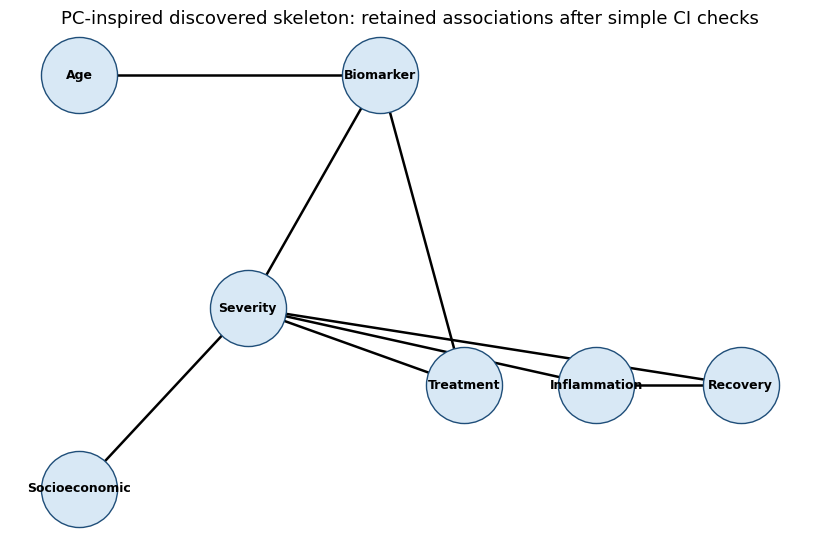

In [48]:
# Use positions from the assumed graph for visual comparability
pos_small = {k: pos[k] for k in variables_for_discovery}

G_skeleton = draw_undirected_graph(
    skeleton_edges,
    pos=pos_small,
    title="PC-inspired discovered skeleton: retained associations after simple CI checks",
    node_color=COLORS["light_blue"]
);

### Interpretation

The discovered skeleton is a **candidate graph structure**, not a confirmed causal graph.

The algorithm keeps an edge when two variables remain associated after the simple independence checks used here. For example, it may retain edges such as:

$$Severity - Treatment$$

$$Severity - Recovery$$

$$Biomarker - Treatment$$

$$Inflammation - Recovery$$

These retained edges are plausible because they correspond to strong relationships in the simulated data-generating process.

The algorithm removes an edge when the association is weak, or when the association becomes weak after conditioning on another variable. This reflects the same intuition as d-separation:

> If conditioning blocks the path between two variables, their association should become small.


However, this simplified learner has important limitations:

- It uses partial correlation, which mainly captures linear relationships.
- It conditions on only one variable at a time.
- It treats binary and continuous variables in the same approximate way.
- It does not handle hidden confounders.
- It does not fully orient edges.
- It can miss real edges if effects are weak or indirect.
- It can retain extra edges when variables are strongly associated through untested paths.

> Therefore, the output should be interpreted as a **starting point for graph refinement**, not as the final causal structure.


---
### 9.3 Orienting edges with temporal and domain knowledge

Causal discovery is often stronger when combined with expert constraints.

In the healthcare example, domain knowledge gives a rough ordering:

$$Age, Socioeconomic \rightarrow Severity, Biomarker \rightarrow Treatment \rightarrow Inflammation \rightarrow Recovery$$

This ordering does not prove the graph, but it prevents impossible directions such as `Recovery` causing baseline `Age`.

The next cell orients discovered skeleton edges according to this ordering.

Oriented edges: [('Age', 'Biomarker'), ('Socioeconomic', 'Severity'), ('Severity', 'Biomarker'), ('Severity', 'Treatment'), ('Severity', 'Inflammation'), ('Severity', 'Recovery'), ('Biomarker', 'Treatment'), ('Inflammation', 'Recovery')]
Unresolved same-level edges: []


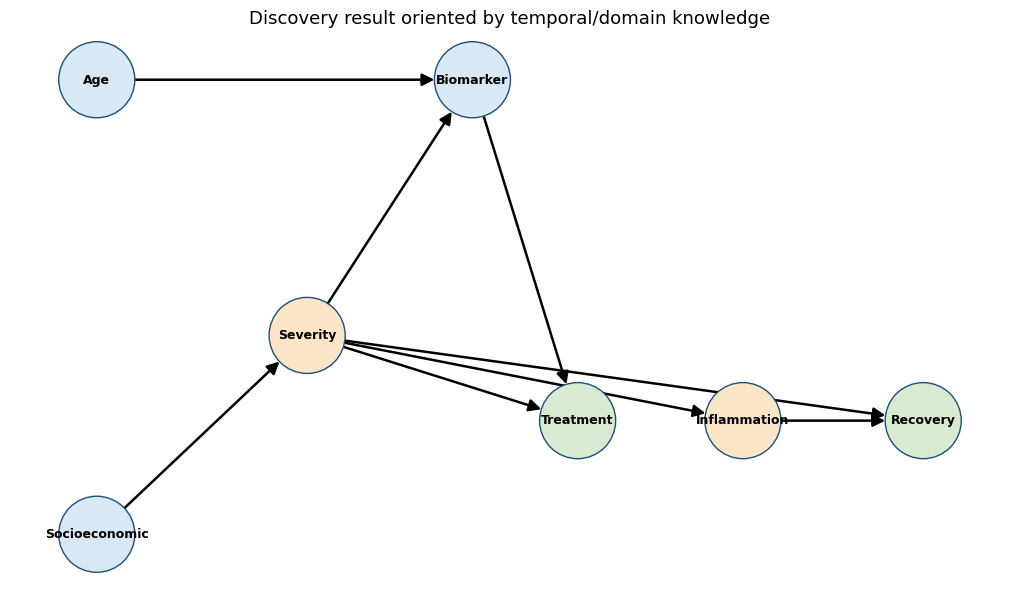

In [49]:
causal_order = {
    "Age": 0,
    "Socioeconomic": 0,
    "Severity": 1,
    "Biomarker": 2,
    "Treatment": 3,
    "Inflammation": 4,
    "Recovery": 5,
}

def orient_by_order(edges, order):
    oriented = []
    undirected = []
    for a, b in edges:
        if order[a] < order[b]:
            oriented.append((a, b))
        elif order[b] < order[a]:
            oriented.append((b, a))
        else:
            undirected.append((a, b))
    return oriented, undirected

oriented_edges, unresolved_edges = orient_by_order(skeleton_edges, causal_order)
print("Oriented edges:", oriented_edges)
print("Unresolved same-level edges:", unresolved_edges)

oriented_colors = {node: COLORS["light_blue"] for node in variables_for_discovery}
oriented_colors["Treatment"] = COLORS["light_green"]
oriented_colors["Recovery"] = COLORS["light_green"]
oriented_colors["Severity"] = COLORS["light_orange"]
oriented_colors["Inflammation"] = COLORS["light_orange"]

G_oriented = draw_dag(
    oriented_edges,
    pos=pos_small,
    title="Discovery result oriented by temporal/domain knowledge",
    node_colors=oriented_colors,
    figsize=(10, 5.5)
);

### Discovery plus domain knowledge

This hybrid workflow is common in real projects:

1. begin with a scientific question,
2. write down domain constraints,
3. run exploratory discovery methods,
4. compare discovered structures with expert expectations,
5. investigate disagreements,
6. refine the graph,
7. estimate causal effects only after the estimand and assumptions are clear.

In applied causal intelligence, the graph is an evolving object: it is refined through data, assumptions, domain expertise, and validation.

---
### 9.4 Functional causal discovery: LiNGAM intuition

The PC-style approach in the previous section is based mainly on **conditional independence**. It can help remove edges and identify some graph structures, but it often cannot fully determine causal direction from observational data.

For example, if two variables are statistically associated, conditional independence alone may not tell us whether:

$$X \rightarrow Y$$

or

$$Y \rightarrow X$$

or whether both are influenced by another variable.

Functional causal discovery methods take a different approach. Instead of relying only on conditional independence, they make assumptions about the **data-generating equations**.

A general functional causal model can be written as:

$$X_i = f_i(Pa(X_i), e_i)$$

where:

- $X_i$ is a variable in the system,
- $Pa(X_i)$ are its causal parents,
- $f_i$ is the structural function that generates $X_i$,
- $e_i$ is an independent noise term.

The key idea is that causal direction may become identifiable if we assume something about the functional form and the noise.

### LiNGAM: Linear Non-Gaussian Acyclic Model

LiNGAM stands for **Linear Non-Gaussian Acyclic Model**. It assumes that each variable is generated as a linear combination of its causal parents plus an independent non-Gaussian noise term:

$$X_i = \sum_{j \in Pa(i)} a_{ij}X_j + e_i$$

where:

- $Pa(i)$ is the set of causal parents of $X_i$,
- $a_{ij}$ is the causal coefficient from $X_j$ to $X_i$,
- $e_i$ is an independent noise term,
- the causal graph is acyclic,
- the noise terms are non-Gaussian and mutually independent.

The non-Gaussian assumption is important. In ordinary linear Gaussian models, the direction of causality is generally not identifiable from observational data alone. A model such as $X \rightarrow Y$ can often fit the data just as well as $Y \rightarrow X$.

LiNGAM breaks this symmetry by using the non-Gaussian structure of the noise. Under its assumptions, the model can sometimes recover a causal ordering and orient edges.

### Why this matters

LiNGAM can be useful when:

- the variables are continuous,
- relationships are approximately linear,
- hidden confounding is limited,
- the noise terms are plausibly non-Gaussian,
- the goal is exploratory causal structure learning.

However, LiNGAM should not be applied mechanically. Its results are only meaningful if its assumptions are plausible for the scientific domain.

### Visual intuition: why non-Gaussian noise matters in LiNGAM

The purpose of this example is to show why LiNGAM requires non-Gaussian noise.

We simulate data from the true causal direction:

$$X \rightarrow Y$$

with the structural equation:

$$Y = aX + e$$

We compare two cases:

1. **Gaussian case:** both $X$ and the noise term $e$ are Gaussian.
2. **Non-Gaussian case:** both $X$ and $e$ are non-Gaussian.

In each case, we fit two regression models:

$$Y \sim X$$

and

$$X \sim Y$$

In ordinary linear regression, the residuals are uncorrelated with the predictor by construction. Therefore, ordinary residual correlation is not enough. To make the dependence more visible, we also examine whether the residual spread depends on the predictor using:

$$Corr(Predictor, Residual^2)$$

In the Gaussian case, both directions tend to look plausible. In the non-Gaussian case, the true direction should produce residuals that are more independent of the predictor, while the reverse direction may show dependence in the residual spread.

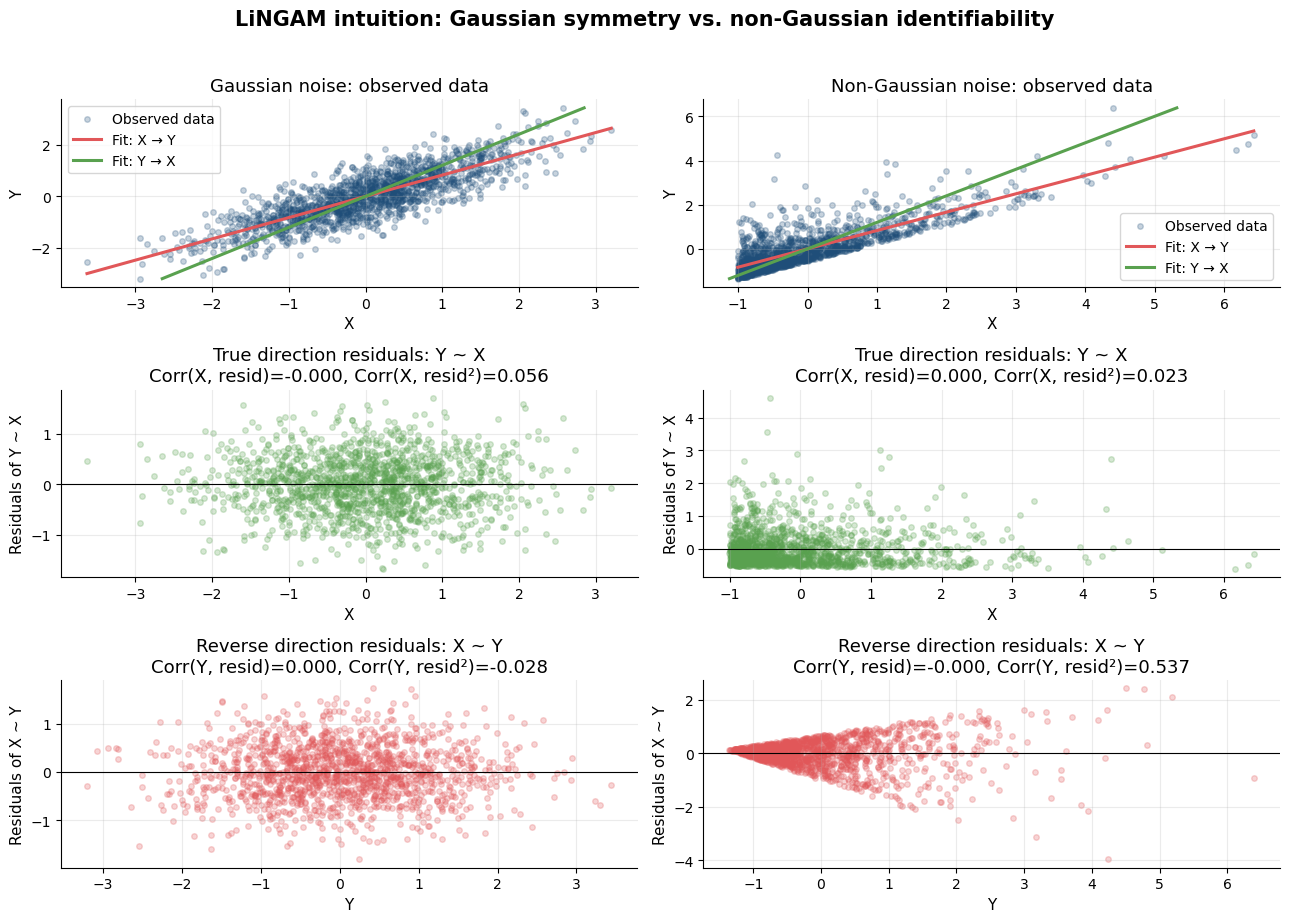

In [50]:
# ---------------------------------------------------------------------
# Simulation for LiNGAM intuition
# ---------------------------------------------------------------------

def simulate_linear_causal_data(n=1500, case="gaussian", seed=42):
    """
    Simulate data from the true causal model X -> Y.

    True structural equation:
        Y = aX + e

    In the Gaussian case, both X and e are Gaussian.
    In the non-Gaussian case, both X and e are centered exponential variables.
    """
    rng = np.random.default_rng(seed)
    a = 1.2

    if case == "gaussian":
        X = rng.normal(0, 1, n)
        e = rng.normal(0, 0.8, n)

    elif case == "non_gaussian":
        # Centered exponential variables are non-Gaussian and skewed.
        X = rng.exponential(1, n) - 1
        e = 0.8 * (rng.exponential(1, n) - 1)

    else:
        raise ValueError("case must be 'gaussian' or 'non_gaussian'.")

    Y = a * X + e

    # Standardize for clearer visualization
    X = (X - X.mean()) / X.std()
    Y = (Y - Y.mean()) / Y.std()

    return X, Y


def fit_residuals(predictor, target):
    """
    Fit target ~ predictor and return fitted values and residuals.
    """
    model = LinearRegression()
    model.fit(predictor.reshape(-1, 1), target)
    fitted = model.predict(predictor.reshape(-1, 1))
    residuals = target - fitted
    return fitted, residuals, model


def dependence_diagnostics(predictor, residuals):
    """
    Simple visual diagnostics for residual dependence.

    In OLS, Corr(predictor, residuals) is usually close to zero by construction.
    Therefore, we also check Corr(predictor, |residuals|) and Corr(predictor, residuals^2).
    These are simple indicators of dependence in spread or variance.
    """
    corr_resid = np.corrcoef(predictor, residuals)[0, 1]
    corr_abs = np.corrcoef(predictor, np.abs(residuals))[0, 1]
    corr_sq = np.corrcoef(predictor, residuals**2)[0, 1]

    return corr_resid, corr_abs, corr_sq


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

def plot_lingam_gaussian_vs_nongaussian(n=1500, seed=42):
    """
    Compare Gaussian and non-Gaussian cases for LiNGAM intuition.
    """
    cases = [
        ("gaussian", "Gaussian noise"),
        ("non_gaussian", "Non-Gaussian noise")
    ]

    fig, axes = plt.subplots(3, 2, figsize=(13, 9))

    for col, (case, title) in enumerate(cases):

        X, Y = simulate_linear_causal_data(n=n, case=case, seed=seed)

        # True direction: Y ~ X
        fitted_y_from_x, resid_y_from_x, model_yx = fit_residuals(X, Y)

        # Reverse direction: X ~ Y
        fitted_x_from_y, resid_x_from_y, model_xy = fit_residuals(Y, X)

        order_x = np.argsort(X)
        order_y = np.argsort(Y)

        # Reverse regression line is X_hat = bY + c.
        # To plot in X-Y coordinates, use x = X_hat and y = Y.
        x_line_reverse = fitted_x_from_y[order_y]
        y_line_reverse = Y[order_y]

        # Diagnostics
        corr_true, abs_true, sq_true = dependence_diagnostics(X, resid_y_from_x)
        corr_rev, abs_rev, sq_rev = dependence_diagnostics(Y, resid_x_from_y)

        # -------------------------------------------------------------
        # Row 1: observed data and regression lines
        # -------------------------------------------------------------
        ax = axes[0, col]
        ax.scatter(X, Y, alpha=0.25, s=16, color=COLORS["navy"], label="Observed data")

        ax.plot(
            X[order_x],
            fitted_y_from_x[order_x],
            color=COLORS["red"],
            linewidth=2.2,
            label="Fit: X → Y"
        )

        ax.plot(
            x_line_reverse,
            y_line_reverse,
            color=COLORS["green"],
            linewidth=2.2,
            label="Fit: Y → X"
        )

        ax.set_title(f"{title}: observed data")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.legend()
        clean_axis(ax)

        # -------------------------------------------------------------
        # Row 2: true direction residuals
        # -------------------------------------------------------------
        ax = axes[1, col]
        ax.scatter(X, resid_y_from_x, alpha=0.25, s=16, color=COLORS["green"])
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(
            "True direction residuals: Y ~ X\n"
            f"Corr(X, resid)={corr_true:.3f}, "
            f"Corr(X, resid²)={sq_true:.3f}"
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Residuals of Y ~ X")
        clean_axis(ax)

        # -------------------------------------------------------------
        # Row 3: reverse direction residuals
        # -------------------------------------------------------------
        ax = axes[2, col]
        ax.scatter(Y, resid_x_from_y, alpha=0.25, s=16, color=COLORS["red"])
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(
            "Reverse direction residuals: X ~ Y\n"
            f"Corr(Y, resid)={corr_rev:.3f}, "
            f"Corr(Y, resid²)={sq_rev:.3f}"
        )
        ax.set_xlabel("Y")
        ax.set_ylabel("Residuals of X ~ Y")
        clean_axis(ax)

    fig.suptitle(
        "LiNGAM intuition: Gaussian symmetry vs. non-Gaussian identifiability",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_lingam_gaussian_vs_nongaussian(n=1500, seed=42)

### Interpretation

The figure compares two situations for the same true causal direction:

$$X \rightarrow Y$$

with the structural equation:

$$Y = aX + e$$

The left column shows the **Gaussian case**. Although the data were generated from $X \rightarrow Y$, both regression directions look plausible. The residual plots are fairly patternless in both directions. The residual-spread diagnostic is also small in both directions:

$$Corr(X, residual^2) = 0.056$$

$$Corr(Y, residual^2) = -0.028$$

This illustrates the symmetry problem in linear Gaussian models. With Gaussian noise, observational data alone often cannot distinguish whether $X$ causes $Y$ or $Y$ causes $X$.

The right column shows the **non-Gaussian case**. Here, the true direction $Y \sim X$ produces residuals that are much closer to independent of the predictor:

$$Corr(X, residual^2) = 0.023$$

However, the reverse direction $X \sim Y$ produces residuals whose spread clearly depends on the predictor:

$$Corr(Y, residual^2) = 0.537$$

The cone-shaped pattern in the lower-right panel shows that the residuals are not independent of $Y$ in the reverse direction. This makes the reverse model less compatible with the idea of an independent noise term.

This is the key intuition behind LiNGAM:

> In the correct causal direction, the residual should behave like an independent noise term. In the wrong direction, this independence is usually violated when the variables are generated by a linear non-Gaussian causal process.

Therefore, LiNGAM does not infer causality from correlation alone. It relies on additional assumptions: linear structural equations, acyclicity, independent noise terms, and non-Gaussianity. When these assumptions are plausible, causal direction can become identifiable from observational data.

</br>

### Example: LiNGAM and the Healthcare Use Case

We now apply the LiNGAM idea to the healthcare example. Since basic LiNGAM is designed for continuous variables with linear structural relationships, we focus only on the continuous part of the simulated dataset:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`
- `Inflammation`

These variables are suitable for a simple LiNGAM demonstration because they are measured on continuous scales and can be interpreted as part of an underlying structural system.

We do **not** include binary variables such as `Treatment`, `Recovery`, and `SpecialistClinic` in this basic example. These variables require additional modeling choices, such as discrete causal discovery methods, generalized structural models, or mixed-data extensions.

The purpose of this example is not to claim that LiNGAM fully recovers the true healthcare graph. Instead, it shows how a functional causal discovery method can propose directed relationships among continuous variables when its assumptions are approximately plausible.

In [51]:
# ---------------------------------------------------------------------
# Functional causal discovery with LiNGAM
# ---------------------------------------------------------------------
# LiNGAM is optional. The notebook should still run if the package is not installed.

try:
    from lingam import DirectLiNGAM
    lingam_available = True
except Exception:
    lingam_available = False
    print("LiNGAM is not installed in this environment.")
    print("In Google Colab, you can install it with:")
    print("!pip install lingam")

if lingam_available:
    # LiNGAM is most appropriate here for continuous variables.
    cont_vars = ["Age", "Socioeconomic", "Severity", "Biomarker", "Inflammation"]

    # Standardize variables before fitting LiNGAM.
    X_lingam = StandardScaler().fit_transform(health[cont_vars])

    # Fit DirectLiNGAM.
    lingam_model = DirectLiNGAM()
    lingam_model.fit(X_lingam)

    # In lingam, adjacency_matrix_[i, j] means j -> i.
    adj = pd.DataFrame(
        lingam_model.adjacency_matrix_,
        index=cont_vars,
        columns=cont_vars
    )

    print("Estimated LiNGAM adjacency matrix")
    print("Rows are target variables; columns are source variables.")
    display(adj.round(2))

    # Convert adjacency matrix into graph edges.
    lingam_edges = []
    edge_labels = {}
    threshold = 0.10

    for target in cont_vars:
        for source in cont_vars:
            weight = adj.loc[target, source]

            if abs(weight) > threshold:
                lingam_edges.append((source, target))
                edge_labels[(source, target)] = f"{weight:.2f}"

    # Draw graph using comparable positions from the main DAG.
    G_lingam = nx.DiGraph()
    G_lingam.add_nodes_from(cont_vars)
    G_lingam.add_edges_from(lingam_edges)

    pos_lingam = {k: pos[k] for k in cont_vars}

    lingam_colors = {node: COLORS["light_blue"] for node in cont_vars}
    lingam_colors["Severity"] = COLORS["light_orange"]
    lingam_colors["Inflammation"] = COLORS["light_orange"]

    plt.figure(figsize=(9, 5))

    nx.draw(
        G_lingam,
        pos_lingam,
        with_labels=True,
        node_size=3000,
        node_color=[lingam_colors.get(node, COLORS["light_blue"]) for node in G_lingam.nodes()],
        edgecolors=COLORS["navy"],
        arrows=True,
        arrowsize=18,
        font_size=9,
        font_weight="bold",
        width=1.8,
    )

    nx.draw_networkx_edge_labels(
        G_lingam,
        pos_lingam,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title("LiNGAM candidate graph for continuous healthcare variables")
    plt.axis("off")
    plt.show()

LiNGAM is not installed in this environment.
In Google Colab, you can install it with:
!pip install lingam


### Interpretation

If LiNGAM is installed and the cell runs successfully, the output includes an estimated adjacency matrix and a candidate directed graph. Each nonzero entry represents a possible directed causal relationship.

In the adjacency matrix, rows are target variables and columns are source variables. Therefore, an entry in row `Severity` and column `Socioeconomic` represents a candidate edge:

$$Socioeconomic \rightarrow Severity$$

The graph visualizes the strongest estimated relationships after applying a threshold to the adjacency matrix.

This result should be interpreted as a **candidate causal structure**, not as a confirmed causal graph. LiNGAM is useful because it can sometimes orient edges from observational data, but this ability depends on strong assumptions.

For this example, LiNGAM is applied only to continuous variables. This is why `Treatment`, `Recovery`, and `SpecialistClinic` are excluded. Those variables are binary in this simulated dataset and are not ideal inputs for a basic linear LiNGAM demonstration.

A good interpretation should ask:

- Are the relationships approximately linear?
- Are the noise terms plausibly non-Gaussian?
- Are the noise terms independent?
- Are important confounders missing?
- Is the system acyclic?
- Are the results stable if we change the variable set or resample the data?

> The main lesson is that functional causal discovery can add information about causal direction, but only under additional assumptions. It complements, rather than replaces, graph reasoning, temporal knowledge, and domain expertise.

</br>

---
## 10. Evaluation in simulation: what did the discovery method recover?

In real causal discovery problems, we usually do not know the true causal graph. This makes evaluation difficult.

In this chapter, however, we simulated the healthcare dataset ourselves. Because we created the data-generating process, we know which variable pairs are truly connected in the simulated graph.

This gives us a useful teaching opportunity. We can compare:

1. the known graph used to generate the data, and
2. the graph proposed by our simplified discovery method.

In this section, we compare only whether two variables are connected. We do not evaluate arrow directions.

For example, both of these directed relationships contain the same connection:

$$Severity \rightarrow Treatment$$

$$Treatment \rightarrow Severity$$

If we ignore direction, both become:

$$Severity - Treatment$$

For this introductory comparison, we ask:

> Did the discovery method find the right variable connections?

We do not yet ask whether it found the correct arrow directions.

In [52]:
# ---------------------------------------------------------------------
# Compare discovered connections with known simulated connections
# ---------------------------------------------------------------------
# This section assumes that the PC-inspired skeleton learner in Section 9.2
# has already been run and that skeleton_edges and variables_for_discovery exist.

def graph_connections(edge_list):
    """
    Convert a list of graph edges into direction-free connections.

    For example, ("Severity", "Treatment") and ("Treatment", "Severity")
    are treated as the same connection.
    """
    return {tuple(sorted(edge)) for edge in edge_list}


# Keep only the true edges among the variables used in the discovery example
true_small_edges = [
    edge for edge in true_edges
    if edge[0] in variables_for_discovery and edge[1] in variables_for_discovery
]

known_connections = graph_connections(true_small_edges)
discovered_connections = graph_connections(skeleton_edges)

correctly_found = known_connections.intersection(discovered_connections)
extra_found = discovered_connections.difference(known_connections)
missed_connections = known_connections.difference(discovered_connections)

n_known = len(known_connections)
n_discovered = len(discovered_connections)
n_correct = len(correctly_found)
n_extra = len(extra_found)
n_missed = len(missed_connections)

precision = n_correct / n_discovered if n_discovered > 0 else 0
recall = n_correct / n_known if n_known > 0 else 0

summary = pd.DataFrame({
    "Quantity": [
        "Known true connections",
        "Discovered connections",
        "Correctly found connections",
        "Extra connections",
        "Missed connections",
        "Precision",
        "Recall",
    ],
    "Value": [
        n_known,
        n_discovered,
        n_correct,
        n_extra,
        n_missed,
        round(precision, 3),
        round(recall, 3),
    ]
})

summary

,Quantity,Value
0,Known true connections,13.000
1,Discovered connections,8.000
2,Correctly found connections,8.000
3,Extra connections,0.000
4,Missed connections,5.000
5,Precision,1.000
6,Recall,0.615


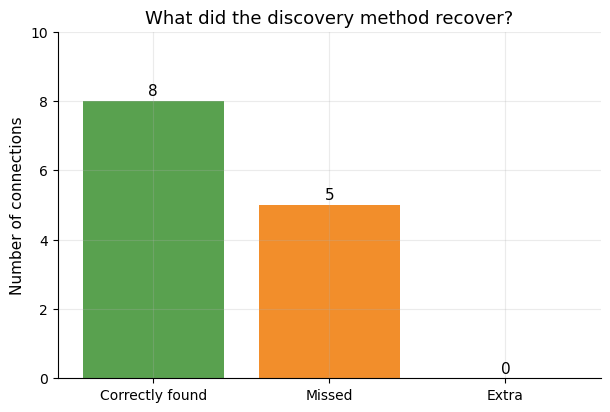

In [53]:
# Visual summary of discovered, missed, and extra connections

fig, ax = plt.subplots(figsize=(7, 4.5))

labels = ["Correctly found", "Missed", "Extra"]
values = [n_correct, n_missed, n_extra]
colors = [COLORS["green"], COLORS["orange"], COLORS["gray"]]

ax.bar(labels, values, color=colors)
ax.set_title("What did the discovery method recover?")
ax.set_ylabel("Number of connections")
ax.set_ylim(0, max(max(values) + 2, 2))

for i, value in enumerate(values):
    ax.text(i, value + 0.15, str(value), ha="center", fontsize=11)

clean_axis(ax)
plt.show()


### What do precision and recall mean here?

**Precision** asks:

> Of the connections found by the discovery method, how many were actually present in the known simulated graph?

In this example, precision is high because the method did not add extra connections.

**Recall** asks:

> Of the true connections in the simulated graph, how many did the discovery method recover?

In this example, recall is lower because the method missed several true connections.

So the discovery method is **conservative** in this example. It finds fewer connections, but the connections it finds are correct.

In [54]:
# ---------------------------------------------------------------------
# Detailed comparison for each variable pair
# ---------------------------------------------------------------------

all_pairs = {
    tuple(sorted((a, b)))
    for i, a in enumerate(variables_for_discovery)
    for b in variables_for_discovery[i + 1:]
}

edge_comparison = []

for pair in sorted(all_pairs):

    in_known = pair in known_connections
    in_discovered = pair in discovered_connections

    if in_known and in_discovered:
        status = "Correctly found"
    elif not in_known and in_discovered:
        status = "Extra connection"
    elif in_known and not in_discovered:
        status = "Missed connection"
    else:
        status = "Correctly absent"

    edge_comparison.append({
        "Variable pair": " -- ".join(pair),
        "In known graph": in_known,
        "In discovered graph": in_discovered,
        "Result": status,
    })

edge_comparison_df = pd.DataFrame(edge_comparison)

# Show only the informative rows
edge_comparison_df[
    edge_comparison_df["Result"].isin([
        "Correctly found",
        "Extra connection",
        "Missed connection"
    ])
]

,Variable pair,In known graph,In discovered graph,Result
0,Age -- Biomarker,True,True,Correctly found
3,Age -- Severity,True,False,Missed connection
8,Biomarker -- Severity,True,True,Correctly found
10,Biomarker -- Treatment,True,True,Correctly found
11,Inflammation -- Recovery,True,True,Correctly found
12,Inflammation -- Severity,True,True,Correctly found
14,Inflammation -- Treatment,True,False,Missed connection
15,Recovery -- Severity,True,True,Correctly found
16,Recovery -- Socioeconomic,True,False,Missed connection
17,Recovery -- Treatment,True,False,Missed connection


### Interpretation

This comparison shows what the simplified discovery method recovered from the simulated data.

The method found 8 connections. All 8 were present in the known simulated graph, so there were no extra connections. However, the known graph contains 13 true connections among these variables, so the method missed 5 connections.

This means the method was conservative:

- it avoided extra connections,
- but it missed some real connections.

This behavior is expected because the method is intentionally simple. It uses correlation and one-variable partial correlation. It can miss connections when:

- the relationship is weak,
- the relationship is partly explained by another variable,
- the effect is indirect,
- the sample is noisy,
- the chosen threshold is too strict,
- the method does not condition on enough variables.

This is not a failure of the example. It is the lesson of the example:

> Causal discovery can help propose candidate graph structures, but it does not automatically recover the true causal graph.

In real research, we usually do not know the true graph. Therefore, we cannot usually compute this type of comparison. Instead, we evaluate a discovered graph using domain knowledge, time ordering, expert review, stability checks, comparison with other methods, and, when possible, experimental or interventional evidence.

The practical conclusion is:

> A discovered graph is a starting point for causal reasoning, not the final answer.

</br>

## 11. Practical checklist for causal graph construction

When building a causal graph for a project, use the following checklist:

1. Define the target causal question.  
   Example: What is the effect of treatment on recovery?

2. Identify the outcome $Y$.  
   Example: `Recovery`.

3. Identify the treatment, exposure, or intervention $T$.  
   Example: `Treatment`.

4. List pre-treatment causes of $T$ and $Y$.  
   Example: `Severity`, `Biomarker`, `Age`, `Socioeconomic`.

5. List post-treatment variables.  
   Example: `Inflammation`.

6. Identify possible colliders or selection variables.  
   Example: `SpecialistClinic`.

7. Draw the initial DAG.

8. Identify backdoor paths.

9. Choose an adjustment set.

10. State assumptions clearly.

11. Use discovery methods only as support for hypothesis generation and graph refinement.

## 12. Chapter Summary

This chapter introduced causal graphs and causal discovery as key components of causal intelligence.

The main message is that causal graphs are not just diagrams. They are **assumption maps**. They make our beliefs about a system explicit, visible, and open to discussion.

Key points from the chapter:

- DAGs help represent assumptions about how variables may influence each other.
- A single healthcare example can contain several important causal structures:
  - `Severity` as a confounder,
  - `Inflammation` as a mediator,
  - `SpecialistClinic` as a collider or selection variable.
- Forks, chains, and colliders are the basic building blocks of graphical causal reasoning.
- d-separation connects graph structure to conditional independence.
- The Causal Markov Condition and Faithfulness explain why graph structure and data patterns can be connected, but only under assumptions.
- Backdoor paths explain why naive observational comparisons can be biased.
- Adjustment is useful when it blocks non-causal paths, but adjustment is not automatic.
- Adjusting for confounders can reduce bias.
- Adjusting for mediators can change the causal question.
- Adjusting for colliders can create bias.
- Backdoor adjustment can be implemented in Python using model-based standardization.
- Causal discovery methods use statistical patterns in data to propose candidate graph structures.
- PC-style methods rely on conditional independence patterns.
- Functional methods such as LiNGAM rely on structural equations and assumptions about independent non-Gaussian noise.
- Discovery results should be interpreted as candidate graphs, not causal truth.
- In simulation, we can compare discovered and known graphs. In real applications, the true graph is usually unknown.
- In applied work, causal graphs should be refined using data, domain knowledge, temporal logic, robustness checks, and, when possible, interventional evidence.

The practical message for the rest of the course is:

> Causal intelligence begins by making assumptions explicit, then using data, domain knowledge, and careful reasoning to test, refine, and act on those assumptions.


## 13. References and Further Reading

The references below support the main concepts covered in this chapter: causal graphs, d-separation, adjustment, causal discovery, and functional causal models.

### Foundational causal graphs and causal inference

- Pearl, J. (2009). [*Causality: Models, Reasoning, and Inference*](https://www.cambridge.org/core/books/causality/B0046844FAE10CBF274D4ACBDAEB5F5B). Cambridge University Press.  
  A foundational reference for graphical causal models, do-calculus, interventions, and causal reasoning.

- Pearl, J., Glymour, M., and Jewell, N. P. (2016). [*Causal Inference in Statistics: A Primer*](https://www.wiley.com/en-us/Causal+Inference+in+Statistics%3A+A+Primer-p-9781119186847). Wiley.  
  A concise and accessible introduction to causal diagrams, confounding, adjustment, and causal effects.

- Hernán, M. A., and Robins, J. M. (2020). [*Causal Inference: What If*](https://miguelhernan.org/whatifbook). Chapman & Hall/CRC.  
  A practical reference for causal questions, interventions, observational studies, and adjustment.

- Peters, J., Janzing, D., and Schölkopf, B. (2017). [*Elements of Causal Inference: Foundations and Learning Algorithms*](https://mitpress.mit.edu/9780262037310/elements-of-causal-inference/). MIT Press.  
  A compact reference connecting causal graphs, structural causal models, and causal discovery.

- Spirtes, P., Glymour, C., and Scheines, R. (2000). [*Causation, Prediction, and Search*](https://mitpress.mit.edu/9780262194402/causation-prediction-and-search/). MIT Press.  
  A classic reference for constraint-based causal discovery, including the PC algorithm and graphical causal modeling.

- Chickering, D. M. (2002). [“Optimal Structure Identification with Greedy Search”](https://www.jmlr.org/papers/v3/chickering02b.html). *Journal of Machine Learning Research*.  
  A foundational paper for score-based structure learning and Greedy Equivalence Search.

### Functional causal discovery and nonlinear discovery

- Shimizu, S., Hoyer, P. O., Hyvärinen, A., and Kerminen, A. (2006). [“A Linear Non-Gaussian Acyclic Model for Causal Discovery”](https://www.jmlr.org/papers/v7/shimizu06a.html). *Journal of Machine Learning Research*.  
  The original LiNGAM paper, explaining how non-Gaussian noise can help identify causal direction in linear acyclic models.

- Hoyer, P. O., Janzing, D., Mooij, J. M., Peters, J., and Schölkopf, B. (2008). [“Nonlinear Causal Discovery with Additive Noise Models”](https://proceedings.neurips.cc/paper_files/paper/2008/hash/f7664060cc52bc6f3d620bcedc94a4b6-Abstract.html). *NeurIPS*.  
  A key reference for additive noise models and functional causal discovery beyond linear models.

- Zhang, K., and Hyvärinen, A. (2009). [“On the Identifiability of the Post-Nonlinear Causal Model”](https://arxiv.org/abs/1205.2599).  
  A reference for post-nonlinear causal models and identifiability under functional assumptions.

### Machine-learning-based causal discovery

- Zheng, X., Aragam, B., Ravikumar, P. K., and Xing, E. P. (2018). [“DAGs with NO TEARS: Continuous Optimization for Structure Learning”](https://arxiv.org/abs/1803.01422). *NeurIPS*.  
  Introduces NOTEARS, a continuous optimization approach to learning DAGs.

- Yu, Y., Chen, J., Gao, T., and Yu, M. (2019). [“DAG-GNN: DAG Structure Learning with Graph Neural Networks”](https://arxiv.org/abs/1904.10098).  
  An example of neural-network-based causal structure learning.

- Runge, J., Nowack, P., Kretschmer, M., Flaxman, S., and Sejdinovic, D. (2019). [“Detecting and Quantifying Causal Associations in Large Nonlinear Time Series Datasets”](https://www.science.org/doi/10.1126/sciadv.aau4996). *Science Advances*.  
  Introduces a scalable framework for causal discovery in nonlinear time-series settings, including ideas used in PCMCI-style workflows.

### Python tools and documentation

- [NetworkX documentation](https://networkx.org/documentation/stable/)  
  Used in this chapter for drawing and inspecting graphs.

- [scikit-learn documentation](https://scikit-learn.org/stable/)  
  Used in this chapter for regression, logistic regression, standardization, and simple model-based adjustment.

- [LiNGAM Python package](https://lingam.readthedocs.io/en/latest/)  
  Optional package for running LiNGAM-based causal discovery examples.

- [causal-learn documentation](https://causal-learn.readthedocs.io/en/latest/)  
  Python package for causal discovery methods including PC, FCI, GES, and related algorithms.

- [Tigramite documentation](https://jakobrunge.github.io/tigramite/)  
  Python package for causal discovery in time-series data.